# EDA — TMDB Movies 2023 (TP Grupal)

**Índice**
1. Carga, tipado y calidad de datos
2. Estadística descriptiva univariada
3. Análisis bivariado: asociaciones y géneros
4. Análisis avanzado (Clase 3): asociación, tests, faltantes, outliers, entropía
5. Preparación de datos (Clases 4-5): split, imputación, outliers, features, discretización, codificación, escalado, faltantes/outliers avanzados y desbalance
6. Conclusiones globales

## 1. Carga, tipado y calidad de datos

En TMDB varios campos numéricos usan 0 o negativos para codificar "sin dato" (budget, revenue, runtime, vote_average sin votos). Los marcamos como NaN al cargar (tratamos los 0 y negativos como ausentes), lo que además evita boxplots e histogramas vacíos más adelante.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

CSV = "TMDB_movie_dataset_v11.csv"
if not os.path.exists(CSV):
    import kagglehub
    ruta = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")
    CSV = os.path.join(ruta, "TMDB_movie_dataset_v11.csv")
df = pd.read_csv(CSV, low_memory=False)

# --- Marcado de centinelas como NaN (el 0/neg codifica "sin dato") ---
df["budget"]       = df["budget"].mask(df["budget"] == 0)
df["revenue"]      = df["revenue"].mask(df["revenue"] <= 0)
df["runtime"]      = df["runtime"].mask(df["runtime"] <= 0)
df["vote_average"] = df["vote_average"].mask(df["vote_count"] == 0)

# --- Tipos ---
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
for c in ["status", "original_language"]:
    df[c] = df[c].astype("category")

print("Shape:", df.shape)
df.head()

Shape: (1499934, 24)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,8.255328e+08,148.0,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,7.017292e+08,169.0,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1.004558e+09,152.0,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2.923706e+09,162.0,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1.518816e+09,143.0,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499934 entries, 0 to 1499933
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   id                    1499934 non-null  int64         
 1   title                 1499914 non-null  object        
 2   vote_average          360934 non-null   float64       
 3   vote_count            1499934 non-null  int64         
 4   status                1499934 non-null  category      
 5   release_date          1144832 non-null  datetime64[ns]
 6   revenue               25431 non-null    float64       
 7   runtime               1024989 non-null  float64       
 8   adult                 1499934 non-null  bool          
 9   backdrop_path         365430 non-null   object        
 10  budget                88251 non-null    float64       
 11  homepage              153486 non-null   object        
 12  imdb_id               687110 non-null   ob

### Diccionario de datos

Documentamos el significado de cada una de las 24 columnas del dataset antes de analizarlas.

In [3]:
diccionario = pd.DataFrame({
    "columna": [
        "id", "title", "vote_average", "vote_count", "status", "release_date",
        "revenue", "runtime", "adult", "backdrop_path", "budget", "homepage",
        "imdb_id", "original_language", "original_title", "overview", "popularity",
        "poster_path", "tagline", "genres", "production_companies",
        "production_countries", "spoken_languages", "keywords",
    ],
    "descripcion": [
        "Identificador único de la película en TMDB",
        "Título de la película (idioma de visualización)",
        "Puntaje promedio de votos de usuarios (0-10)",
        "Cantidad de votos recibidos",
        "Estado de producción (Released, Post Production, etc.)",
        "Fecha de estreno",
        "Ingresos de taquilla en USD",
        "Duración en minutos",
        "Indicador de contenido para adultos",
        "Ruta de la imagen de fondo en TMDB",
        "Presupuesto de producción en USD",
        "URL del sitio oficial",
        "Identificador de la película en IMDB",
        "Idioma original (código ISO)",
        "Título original",
        "Sinopsis de la película",
        "Índice interno de popularidad de TMDB",
        "Ruta de la imagen de póster en TMDB",
        "Frase promocional (tagline)",
        "Géneros, string separado por comas (relación 1 a muchos)",
        "Productoras asociadas",
        "Países de producción",
        "Idiomas hablados en la película",
        "Palabras clave asociadas a la película",
    ],
})
diccionario

,columna,descripcion
0,id,Identificador único de la película en TMDB
1,title,Título de la película (idioma de visualización)
2,vote_average,Puntaje promedio de votos de usuarios (0-10)
3,vote_count,Cantidad de votos recibidos
4,status,"Estado de producción (Released, Post Productio..."
5,release_date,Fecha de estreno
6,revenue,Ingresos de taquilla en USD
7,runtime,Duración en minutos
8,adult,Indicador de contenido para adultos
9,backdrop_path,Ruta de la imagen de fondo en TMDB


### Calidad de datos: valores faltantes

Calculamos nulos por columna sobre las 24 columnas, ya con los centinelas marcados como NaN, ordenados de mayor a menor porcentaje.

In [4]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(1),
    "dtype": df.dtypes.astype(str),
}).sort_values("%_nulos", ascending=False)
nulos

,nulos,%_nulos,dtype
revenue,1474503,98.3,float64
budget,1411683,94.1,float64
homepage,1346448,89.8,object
tagline,1289883,86.0,object
vote_average,1139000,75.9,float64
keywords,1136012,75.7,object
backdrop_path,1134504,75.6,object
production_companies,870629,58.0,object
imdb_id,812824,54.2,object
production_countries,741402,49.4,object


Los faltantes son muy desiguales entre columnas: revenue (98.3%) y budget (94.1%) encabezan la lista, seguidos por homepage (89.8%), tagline (86.0%) y vote_average (75.9%); en el otro extremo, popularity, status y vote_count no tienen nulos. El porqué de esta cobertura tan dispar (mecanismos MCAR/MAR/MNAR) se analiza más adelante, en la sección de faltantes.

## 2. Estadística descriptiva univariada

Definimos las variables numéricas de foco (`num_foco`) y describimos su distribución central y de dispersión.

In [5]:
num_foco = ["vote_average", "runtime", "budget", "revenue", "vote_count", "popularity"]

df[num_foco].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
vote_average,360934.0,6.2,2.0,0.0,5.0,6.0,7.2,1.000000e+01
runtime,1024989.0,63.1,63.9,1.0,14.0,60.0,94.0,1.440000e+04
budget,88251.0,3906285.9,21378230.1,1.0,150.0,2500.0,100000.0,1.000000e+09
revenue,25431.0,35799575.7,147874437.3,1.0,993.5,595112.0,12361001.0,5.000000e+09
vote_count,1499934.0,14.3,277.4,0.0,0.0,0.0,0.0,3.449500e+04
popularity,1499934.0,1.0,6.6,0.0,0.0,0.6,0.7,2.994400e+03


In [6]:
momentos = pd.DataFrame({
    "media": df[num_foco].mean(),
    "mediana": df[num_foco].median(),
    "desv_std": df[num_foco].std(),
    "skew": df[num_foco].skew(),
    "kurtosis": df[num_foco].kurtosis(),
}).round(2)
momentos

,media,mediana,desv_std,skew,kurtosis
vote_average,6.16,6.0,2.030000e+00,-0.16,0.26
runtime,63.09,60.0,6.386000e+01,35.45,6375.96
budget,3906285.88,2500.0,2.137823e+07,16.49,478.77
revenue,35799575.70,595112.0,1.478744e+08,13.13,299.14
vote_count,14.31,0.0,2.773800e+02,47.07,3031.75
popularity,0.96,0.6,6.620000e+00,197.67,64363.65


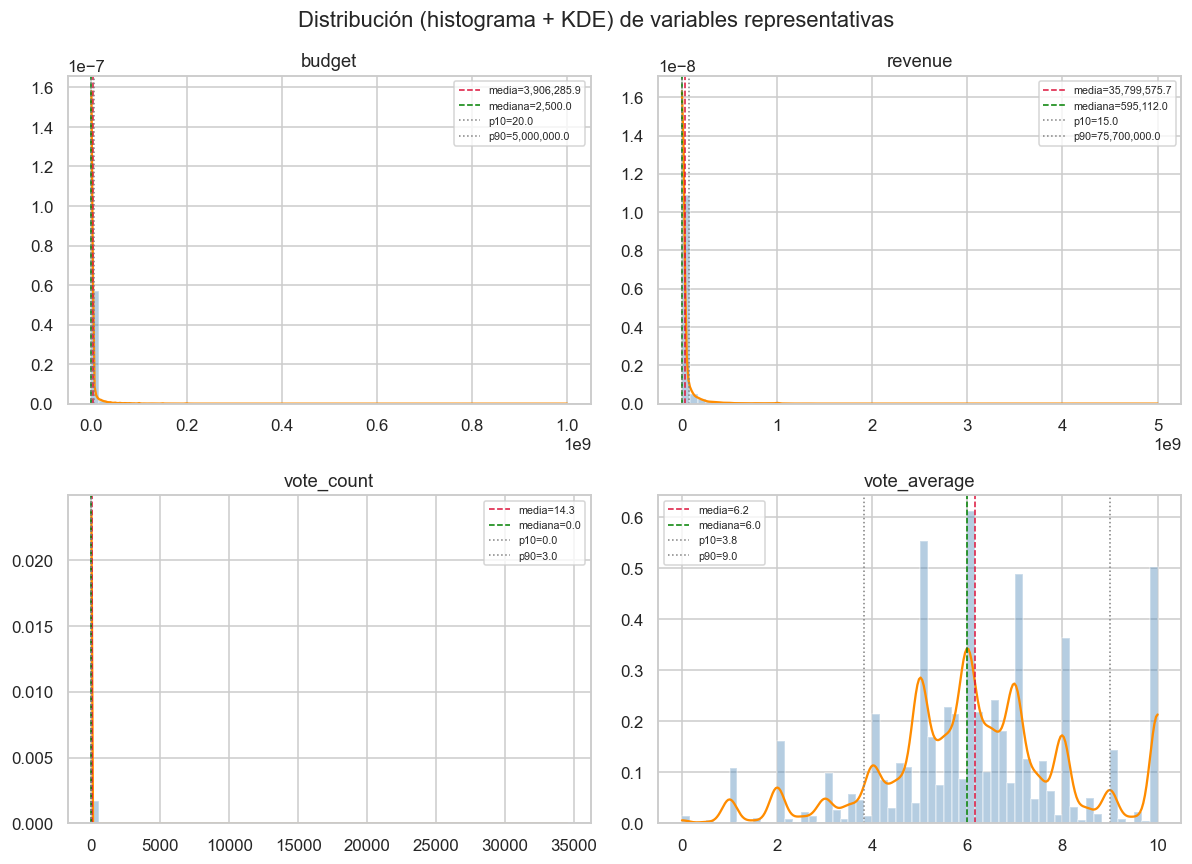

In [7]:
from scipy.stats import gaussian_kde

vars_hist = ["budget", "revenue", "vote_count", "vote_average"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, col in zip(axes.ravel(), vars_hist):
    serie = df[col].dropna()

    ax.hist(serie, bins=60, density=True, alpha=0.4, color="steelblue")
    kde = gaussian_kde(serie)
    xs = np.linspace(serie.min(), serie.max(), 300)
    ax.plot(xs, kde(xs), color="darkorange", lw=1.5)

    media, mediana = serie.mean(), serie.median()
    p10, p90 = serie.quantile([0.1, 0.9])
    ax.axvline(media, color="crimson", ls="--", lw=1, label=f"media={media:,.1f}")
    ax.axvline(mediana, color="green", ls="--", lw=1, label=f"mediana={mediana:,.1f}")
    ax.axvline(p10, color="gray", ls=":", lw=1, label=f"p10={p10:,.1f}")
    ax.axvline(p90, color="gray", ls=":", lw=1, label=f"p90={p90:,.1f}")
    ax.set_title(col)
    ax.legend(fontsize=7)

fig.suptitle("Distribución (histograma + KDE) de variables representativas")
plt.tight_layout()
plt.show()

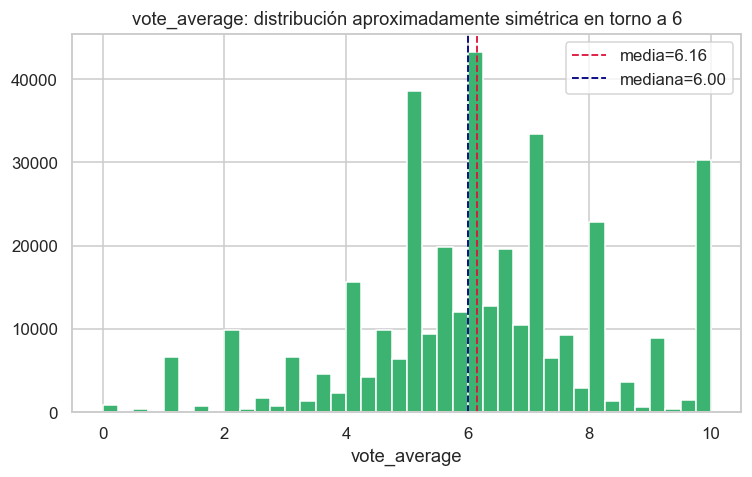

In [8]:
serie_va = df["vote_average"].dropna()
plt.figure(figsize=(7, 4.5))
plt.hist(serie_va, bins=40, color="mediumseagreen", edgecolor="white")
plt.axvline(serie_va.mean(), color="crimson", ls="--", lw=1.2, label=f"media={serie_va.mean():.2f}")
plt.axvline(serie_va.median(), color="navy", ls="--", lw=1.2, label=f"mediana={serie_va.median():.2f}")
plt.title("vote_average: distribución aproximadamente simétrica en torno a 6")
plt.xlabel("vote_average")
plt.legend()
plt.tight_layout()
plt.show()

`vote_average` tiene media 6.16 y mediana 6.0, con forma aproximadamente simétrica (skew -0.16). En budget, revenue, vote_count y popularity conviene distinguir dos fenómenos separados. Primero, la enorme proporción de datos ausentes (budget 94% y revenue 98% nulos): en esas columnas la mayoría de los títulos **no informa** un valor. Segundo, **entre los valores efectivamente observados**, la distribución es fuertemente asimétrica a derecha (popularity con skew ≈198): unos pocos títulos con cifras muy altas frente a muchos de valor bajo. La asimetría describe lo observado; la ausencia masiva de dato es un fenómeno aparte, que se analiza en la sección de faltantes.

### 2.6 Frecuencia de variables categóricas y multivaluadas

Antes de codificarlas (etapa 5) miramos la frecuencia de cada categoría. Esto permite fijar el corte del multi-hot por **% de apariciones** —en lugar de un top-N arbitrario— y ver la cardinalidad real de cada variable.

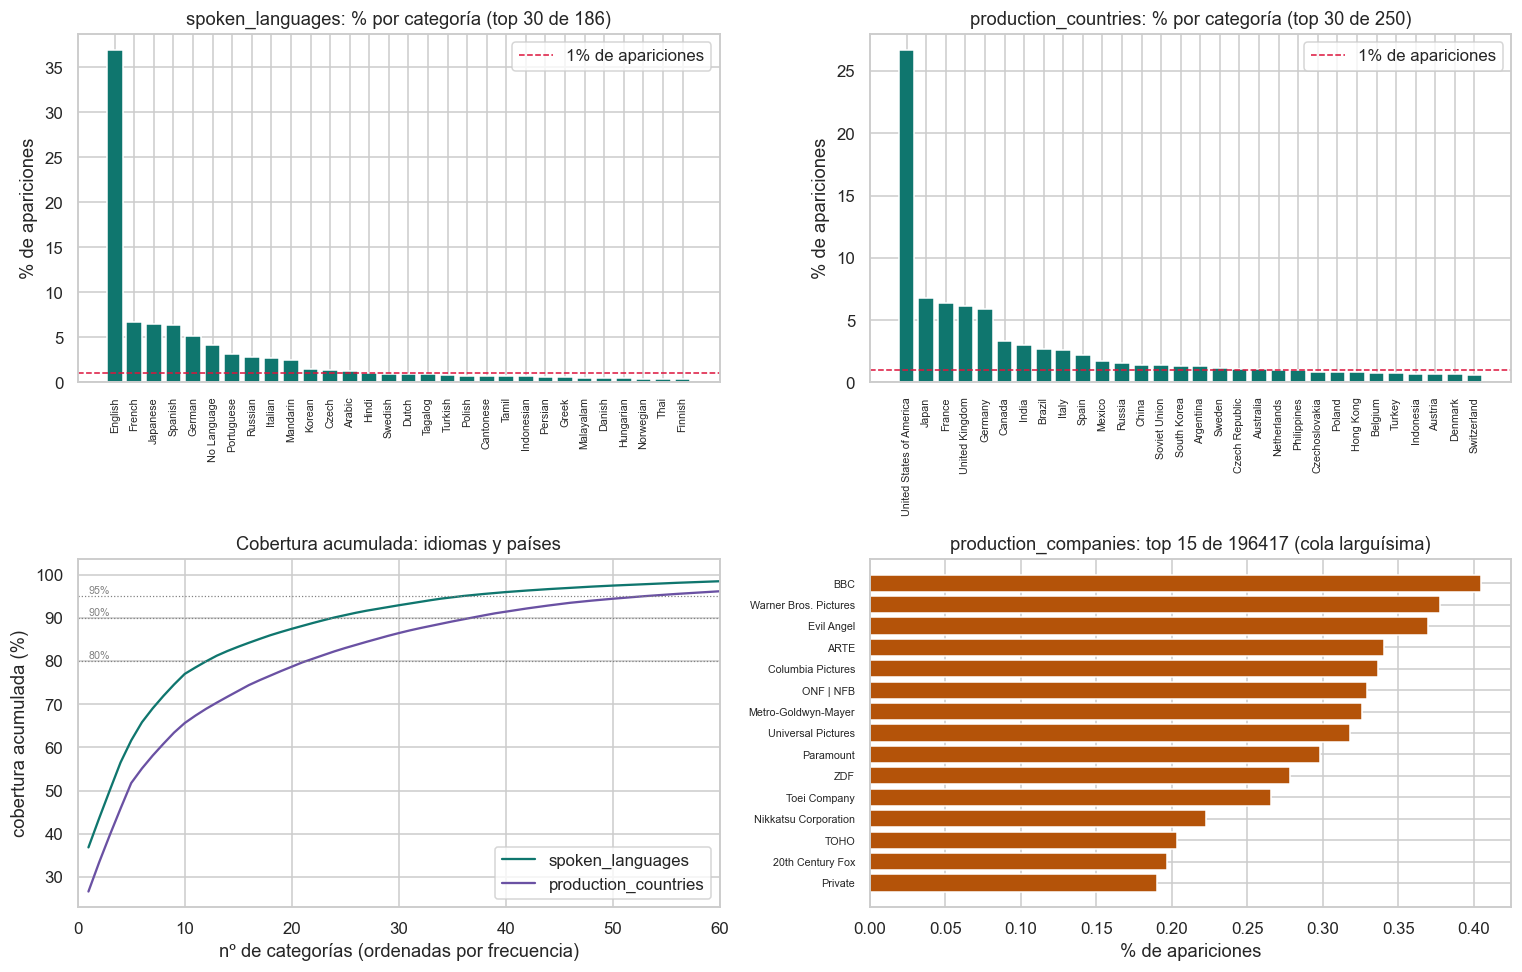

In [9]:
# Frecuencia de categorías (sobre el total). Las multivaluadas se separan por ", ".
def _tokens(col):
    s = df[col].dropna().str.split(", ").explode().str.strip()
    return s[s != ""]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# % por categoría (top 30) con línea de referencia en 1%
for ax, col in [(axes[0, 0], "spoken_languages"), (axes[0, 1], "production_countries")]:
    vc = _tokens(col).value_counts()
    top = (vc / vc.sum() * 100).head(30)
    ax.bar(range(len(top)), top.values, color="#0F766E")
    ax.axhline(1.0, color="crimson", ls="--", lw=1, label="1% de apariciones")
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels(top.index, rotation=90, fontsize=7)
    ax.set_ylabel("% de apariciones")
    ax.set_title(f"{col}: % por categoría (top 30 de {len(vc)})")
    ax.legend()

# curva de cobertura acumulada
ax = axes[1, 0]
for col, color in [("spoken_languages", "#0F766E"), ("production_countries", "#6a51a3")]:
    vc = _tokens(col).value_counts()
    cum = vc.cumsum() / vc.sum() * 100
    ax.plot(range(1, len(cum) + 1), cum.values, label=col, color=color)
for thr in (80, 90, 95):
    ax.axhline(thr, color="grey", ls=":", lw=0.8)
    ax.text(1, thr + 0.5, f"{thr}%", fontsize=7, color="grey")
ax.set_xlim(0, 60)
ax.set_xlabel("nº de categorías (ordenadas por frecuencia)")
ax.set_ylabel("cobertura acumulada (%)")
ax.set_title("Cobertura acumulada: idiomas y países")
ax.legend()

# production_companies: top 15 -> evidencia la cola larguísima
ax = axes[1, 1]
vc = _tokens("production_companies").value_counts()
top = (vc / vc.sum() * 100).head(15)
ax.barh(range(len(top))[::-1], top.values, color="#b45309")
ax.set_yticks(range(len(top))[::-1])
ax.set_yticklabels(top.index, fontsize=7)
ax.set_xlabel("% de apariciones")
ax.set_title(f"production_companies: top 15 de {len(vc)} (cola larguísima)")

plt.tight_layout()
plt.show()

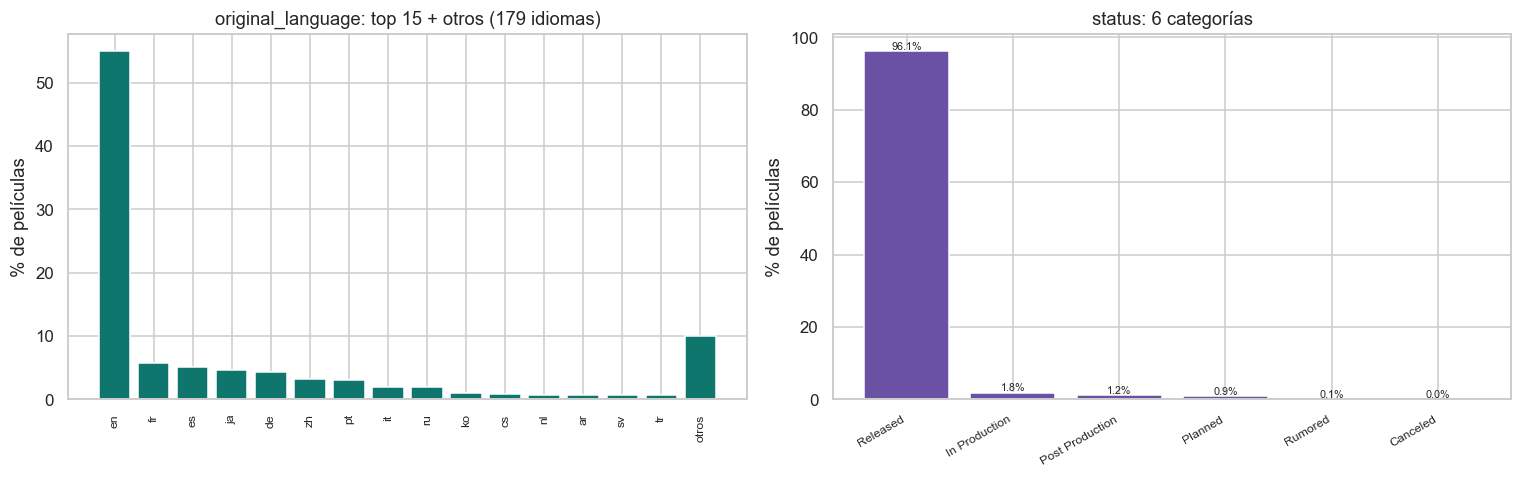

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# original_language: top 15 + "otros"
vc = df["original_language"].value_counts()
pct = vc / vc.sum() * 100
top = pct.head(15)
labels = list(top.index) + ["otros"]
vals = list(top.values) + [pct.iloc[15:].sum()]
axes[0].bar(range(len(labels)), vals, color="#0F766E")
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=90, fontsize=8)
axes[0].set_ylabel("% de películas")
axes[0].set_title(f"original_language: top 15 + otros ({len(vc)} idiomas)")

# status: 6 categorías
pct = df["status"].value_counts() / len(df) * 100
axes[1].bar(range(len(pct)), pct.values, color="#6a51a3")
axes[1].set_xticks(range(len(pct)))
axes[1].set_xticklabels(pct.index, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("% de películas")
axes[1].set_title("status: 6 categorías")
for i, v in enumerate(pct.values):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## 3. Análisis bivariado: asociaciones y géneros

Cruzamos las variables numéricas entre sí y con los géneros para ver qué se mueve junto con qué.

**Nota metodológica.** Las asociaciones y tests se calculan sobre los datos disponibles (borrado por pares: `.corr()` de pandas descarta los pares con NaN). No se imputa antes del análisis —eso distorsionaría las correlaciones y podría filtrar información—; la imputación se difiere a la Sección 5, después del split, que es la práctica habitual para no sesgar las asociaciones.

In [11]:
genre_long = (df[["id", "genres"]].dropna(subset=["genres"])
              .assign(genre=lambda d: d["genres"].str.split(", "))
              .explode("genre"))
genre_long["genre"] = genre_long["genre"].str.strip()
genre_long = genre_long[genre_long["genre"] != ""]

print("géneros únicos:", genre_long["genre"].nunique())
print("películas con género informado:", genre_long["id"].nunique())

géneros únicos: 19
películas con género informado: 826540


Top 10 géneros por cantidad de películas (cada película puede aportar a varios géneros).

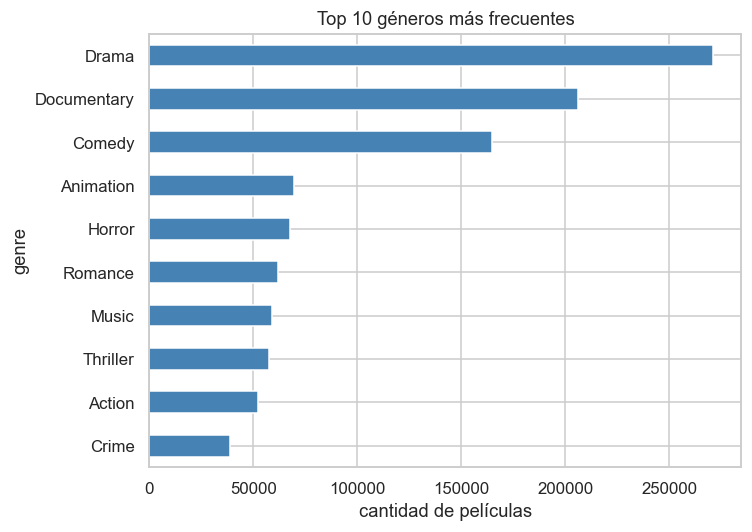

In [12]:
top10_generos = genre_long["genre"].value_counts().head(10)

plt.figure(figsize=(7, 5))
top10_generos.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("cantidad de películas")
plt.title("Top 10 géneros más frecuentes")
plt.tight_layout()
plt.show()

Distribución de `vote_average` para las películas de los 5 géneros más frecuentes.

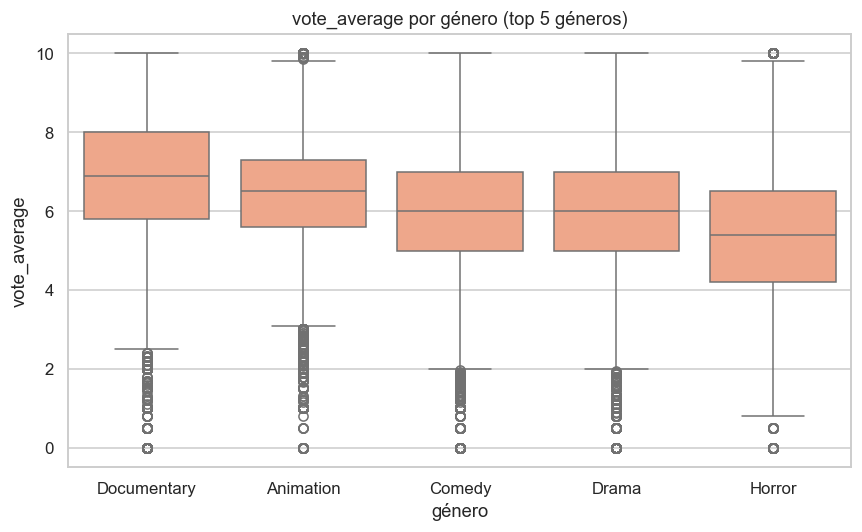

In [13]:
top5_generos = top10_generos.head(5).index.tolist()

genero_rating = (genre_long[genre_long["genre"].isin(top5_generos)]
                  .merge(df[["id", "vote_average"]], on="id", how="left")
                  .dropna(subset=["vote_average"]))

plt.figure(figsize=(8, 5))
orden = genero_rating.groupby("genre")["vote_average"].median().sort_values(ascending=False).index
sns.boxplot(data=genero_rating, x="genre", y="vote_average", order=orden, color="lightsalmon")
plt.xlabel("género")
plt.ylabel("vote_average")
plt.title("vote_average por género (top 5 géneros)")
plt.tight_layout()
plt.show()

Matriz de correlación de Pearson entre las numéricas de foco (`num_foco`).

In [14]:
corr_pearson = df[num_foco].corr(method="pearson")
corr_pearson.round(2)

,vote_average,runtime,budget,revenue,vote_count,popularity
vote_average,1.00,0.03,-0.02,0.08,0.04,0.01
runtime,0.03,1.00,0.26,0.15,0.05,0.05
budget,-0.02,0.26,1.00,0.56,0.47,0.23
revenue,0.08,0.15,0.56,1.00,0.52,0.18
vote_count,0.04,0.05,0.47,0.52,1.00,0.26
popularity,0.01,0.05,0.23,0.18,0.26,1.00


Pearson captura relación **lineal**; Spearman captura relación **monótona** (más robusta a asimetrías).

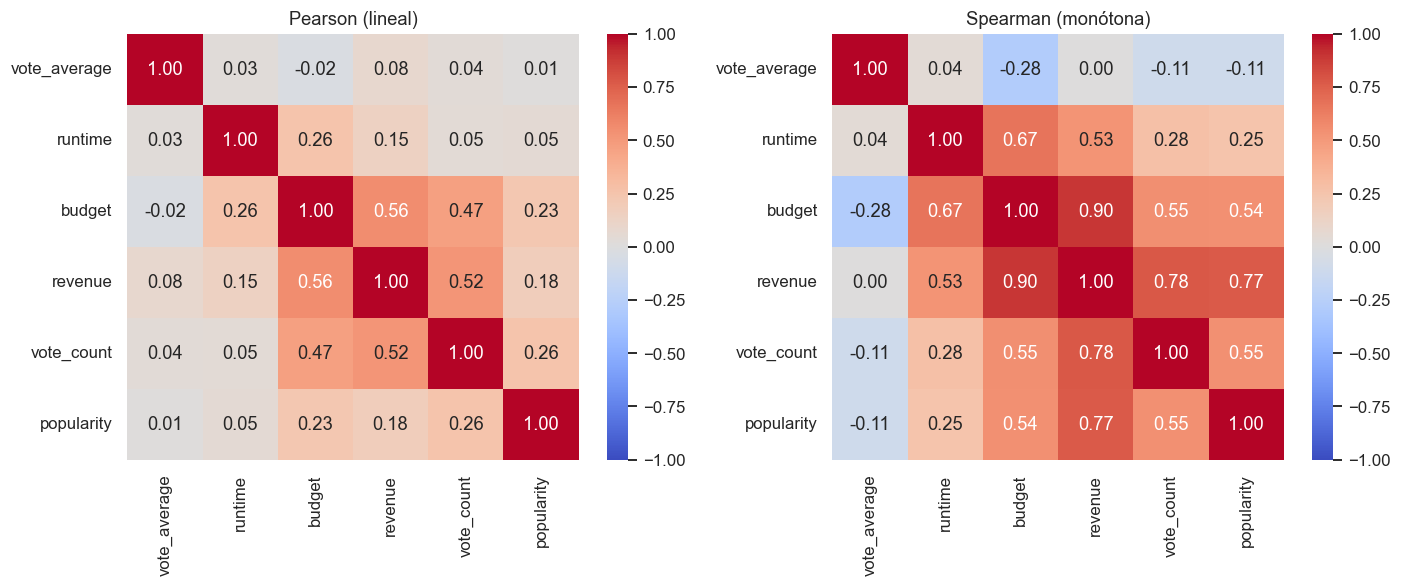

In [15]:
corr_spearman = df[num_foco].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson (lineal)")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman (monótona)")
plt.tight_layout()
plt.show()

Scatters sobre el total de datos disponibles (tras descartar nulos). Escala log-log para budget-revenue por su asimetría extrema.

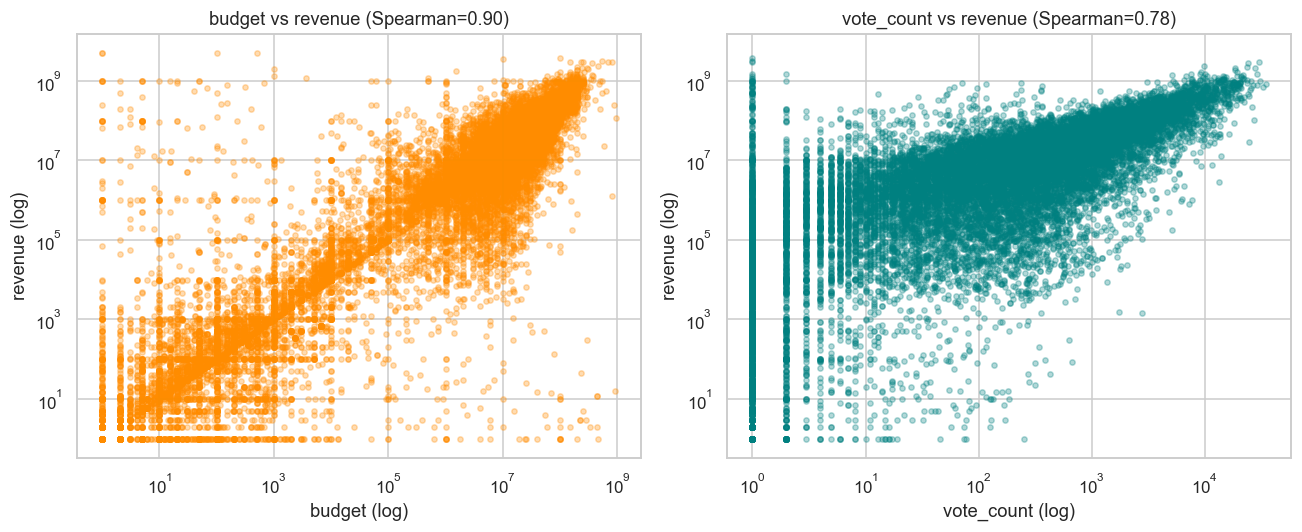

In [16]:
from scipy.stats import spearmanr

muestra_br = df[["budget", "revenue"]].dropna()
rho_br, _ = spearmanr(muestra_br["budget"], muestra_br["revenue"])

muestra_vr = df[["vote_count", "revenue"]].dropna()
rho_vr, _ = spearmanr(muestra_vr["vote_count"], muestra_vr["revenue"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(muestra_br["budget"], muestra_br["revenue"], alpha=0.3, s=12, color="darkorange")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("budget (log)"); axes[0].set_ylabel("revenue (log)")
axes[0].set_title(f"budget vs revenue (Spearman={rho_br:.2f})")

axes[1].scatter(muestra_vr["vote_count"], muestra_vr["revenue"], alpha=0.3, s=12, color="teal")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("vote_count (log)"); axes[1].set_ylabel("revenue (log)")
axes[1].set_title(f"vote_count vs revenue (Spearman={rho_vr:.2f})")
plt.tight_layout()
plt.show()

budget–revenue tiene Pearson 0.56 pero Spearman 0.90: la asociación monótona es fuerte.
vote_average se asocia débil o nulamente con
budget/revenue/vote_count (valores cercanos a 0, incluso -0.28 con budget en Spearman). revenue y
popularity se asocian con fuerza (Spearman 0.77). Todo esto es **asociación** (Pearson=lineal,
Spearman=monótona), no evidencia de causalidad.

Cautela: con budget 94% nulo y revenue 98% nulo, estas correlaciones se calculan sobre una submuestra chica y posiblemente sesgada de títulos con datos financieros.

## 4. Análisis avanzado (Clase 3)
Asociación categoría-numérica (η²), tests de hipótesis, mecanismos de faltantes, outliers cuantitativos y entropía de géneros.

In [17]:
!pip install -q missingno scikit-learn imbalanced-learn
import missingno as msno
from scipy.stats import pearsonr, spearmanr, kendalltau, entropy, ttest_ind


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### 4.1 Medidas de asociación — η² one-vs-rest
η² mide qué proporción de la varianza de una variable numérica está asociada a pertenecer o no a un género. Es descriptivo, no implica causalidad.

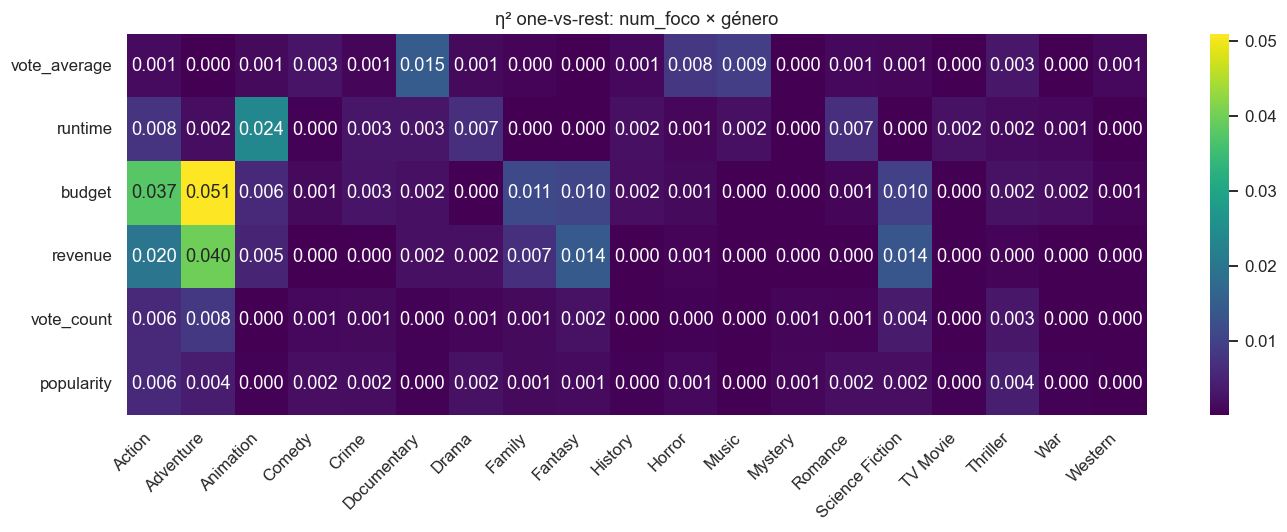

Escala interpretativa η² (Cohen): <0.01 trivial · 0.01-0.06 pequeño · 0.06-0.14 mediano · >0.14 grande.


In [18]:
def eta_squared(categorias, valores):
    tmp = pd.DataFrame({"cat": categorias, "val": valores}).dropna()
    media_global = tmp["val"].mean()
    ss_total = ((tmp["val"] - media_global) ** 2).sum()
    if ss_total == 0:
        return np.nan
    ss_entre = tmp.groupby("cat")["val"].apply(lambda x: len(x) * (x.mean() - media_global) ** 2).sum()
    return ss_entre / ss_total

# indicadores binarios de género a nivel película (filtrando géneros con >=8 casos)
generos_ind = pd.get_dummies(genre_long.set_index("id")["genre"]).groupby("id").max()
generos_validos = generos_ind.columns[generos_ind.sum() >= 8]
generos_ind = generos_ind[generos_validos].astype(int)

df_gen = df.merge(generos_ind, left_on="id", right_index=True, how="left")
df_gen[generos_validos] = df_gen[generos_validos].fillna(0)

filas = []
for var in num_foco:
    filas.append({g: eta_squared(df_gen[g], df_gen[var]) for g in generos_validos})
eta_matrix = pd.DataFrame(filas, index=num_foco)

plt.figure(figsize=(13, 5))
sns.heatmap(eta_matrix, annot=True, fmt=".3f", cmap="viridis")
plt.title("η² one-vs-rest: num_foco × género")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Escala interpretativa η² (Cohen): <0.01 trivial · 0.01-0.06 pequeño · 0.06-0.14 mediano · >0.14 grande.")

Lectura del heatmap: todos los η² son chicos. El género explica muy poca de la varianza de las variables numéricas; el valor más alto es Documentary sobre `vote_average` (η²≈0.015), que en la escala de Cohen es un efecto trivial-a-pequeño. Es decir, pertenecer o no a un género casi no ordena los valores de budget, revenue, popularity, etc.: la asociación numérica–categórica es débil. Es descriptivo, no causal.

### 4.2 Tests de hipótesis
Formalizamos cada asociación con un test y un nivel α=0.05: si el p-valor < α se rechaza H0. El t-test compara medias entre dos grupos. Ninguno mide causalidad.

In [19]:
alpha = 0.05
pares = [("budget", "revenue"), ("budget", "vote_count"), ("revenue", "vote_count"),
         ("budget", "popularity"), ("revenue", "popularity")]
filas = []
for a, b in pares:
    sub = df[[a, b]].dropna()
    r_p, p_p = pearsonr(sub[a], sub[b])
    r_s, p_s = spearmanr(sub[a], sub[b])
    filas.append({"par": f"{a}–{b}", "n": len(sub),
                  "pearson_r": round(r_p, 3), "p_pearson": p_p,
                  "spearman_r": round(r_s, 3), "p_spearman": p_s,
                  "decisión (α=0.05)": "rechazo H0" if p_p < alpha else "no rechazo"})
tabla_tests = pd.DataFrame(filas)
print("H0: r = 0 (no hay asociación lineal)  |  H1: r ≠ 0")
tabla_tests

H0: r = 0 (no hay asociación lineal)  |  H1: r ≠ 0


,par,n,pearson_r,p_pearson,spearman_r,p_spearman,decisión (α=0.05)
0,budget–revenue,18386,0.561,0.000000e+00,0.895,0.0,rechazo H0
1,budget–vote_count,88251,0.467,0.000000e+00,0.550,0.0,rechazo H0
2,revenue–vote_count,25431,0.522,0.000000e+00,0.778,0.0,rechazo H0
3,budget–popularity,88251,0.230,0.000000e+00,0.542,0.0,rechazo H0
4,revenue–popularity,25431,0.179,3.946368e-182,0.768,0.0,rechazo H0


In [20]:
print("H0: la media de vote_average es igual dentro y fuera del género | H1: difieren")
# t-test in-vs-out del género con mayor η² sobre vote_average
genero_top_va = eta_matrix.loc["vote_average"].idxmax()
grupo_in = df_gen.loc[df_gen[genero_top_va] == 1, "vote_average"].dropna()
grupo_out = df_gen.loc[df_gen[genero_top_va] == 0, "vote_average"].dropna()
t_stat, p_val = ttest_ind(grupo_in, grupo_out, equal_var=False)

print(f"Género más asociado a vote_average (η² máx): {genero_top_va} (η²={eta_matrix.loc['vote_average', genero_top_va]:.4f})")
print(f"t = {t_stat:.2f}, p = {p_val:.3g}")
print(f"media in={grupo_in.mean():.2f} (n={len(grupo_in)}) | media out={grupo_out.mean():.2f} (n={len(grupo_out)})")

H0: la media de vote_average es igual dentro y fuera del género | H1: difieren
Género más asociado a vote_average (η² máx): Documentary (η²=0.0146)
t = 74.47, p = 0
media in=6.76 (n=50851) | media out=6.06 (n=310083)


**Conclusión ítem por ítem.** En los 5 pares el p-valor es prácticamente 0 (« α=0.05) → se rechaza H0 en todos: hay asociación lineal/monótona estadísticamente significativa (la más fuerte, budget–revenue). En el t-test, p≈0 → se rechaza H0: los documentales tienen `vote_average` medio más alto (≈6.76 vs 6.06). 

### 4.3 Mecanismos de faltantes
`missingno` visualiza patrones de nulidad sobre una muestra; comparamos además el % de faltantes por década y por género principal.

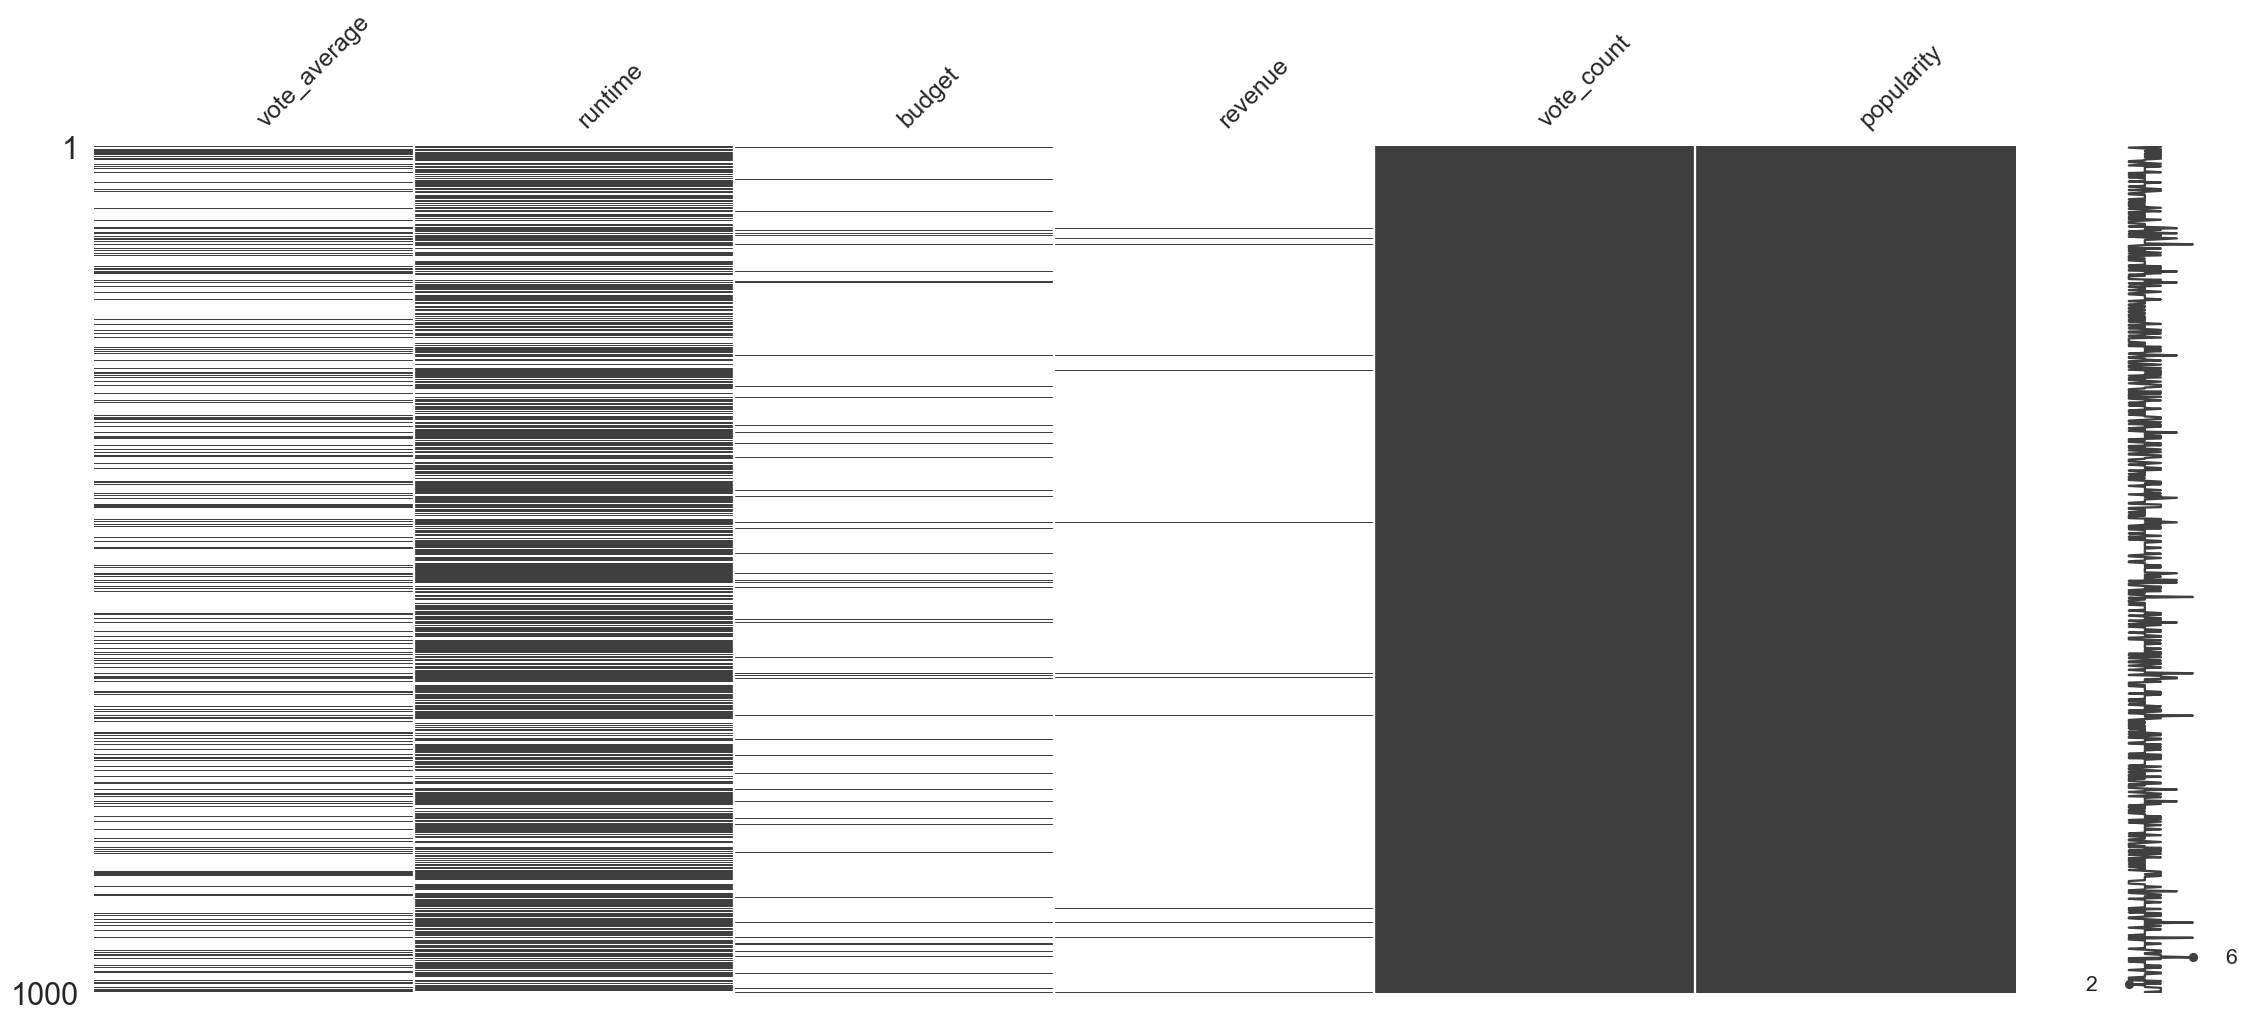

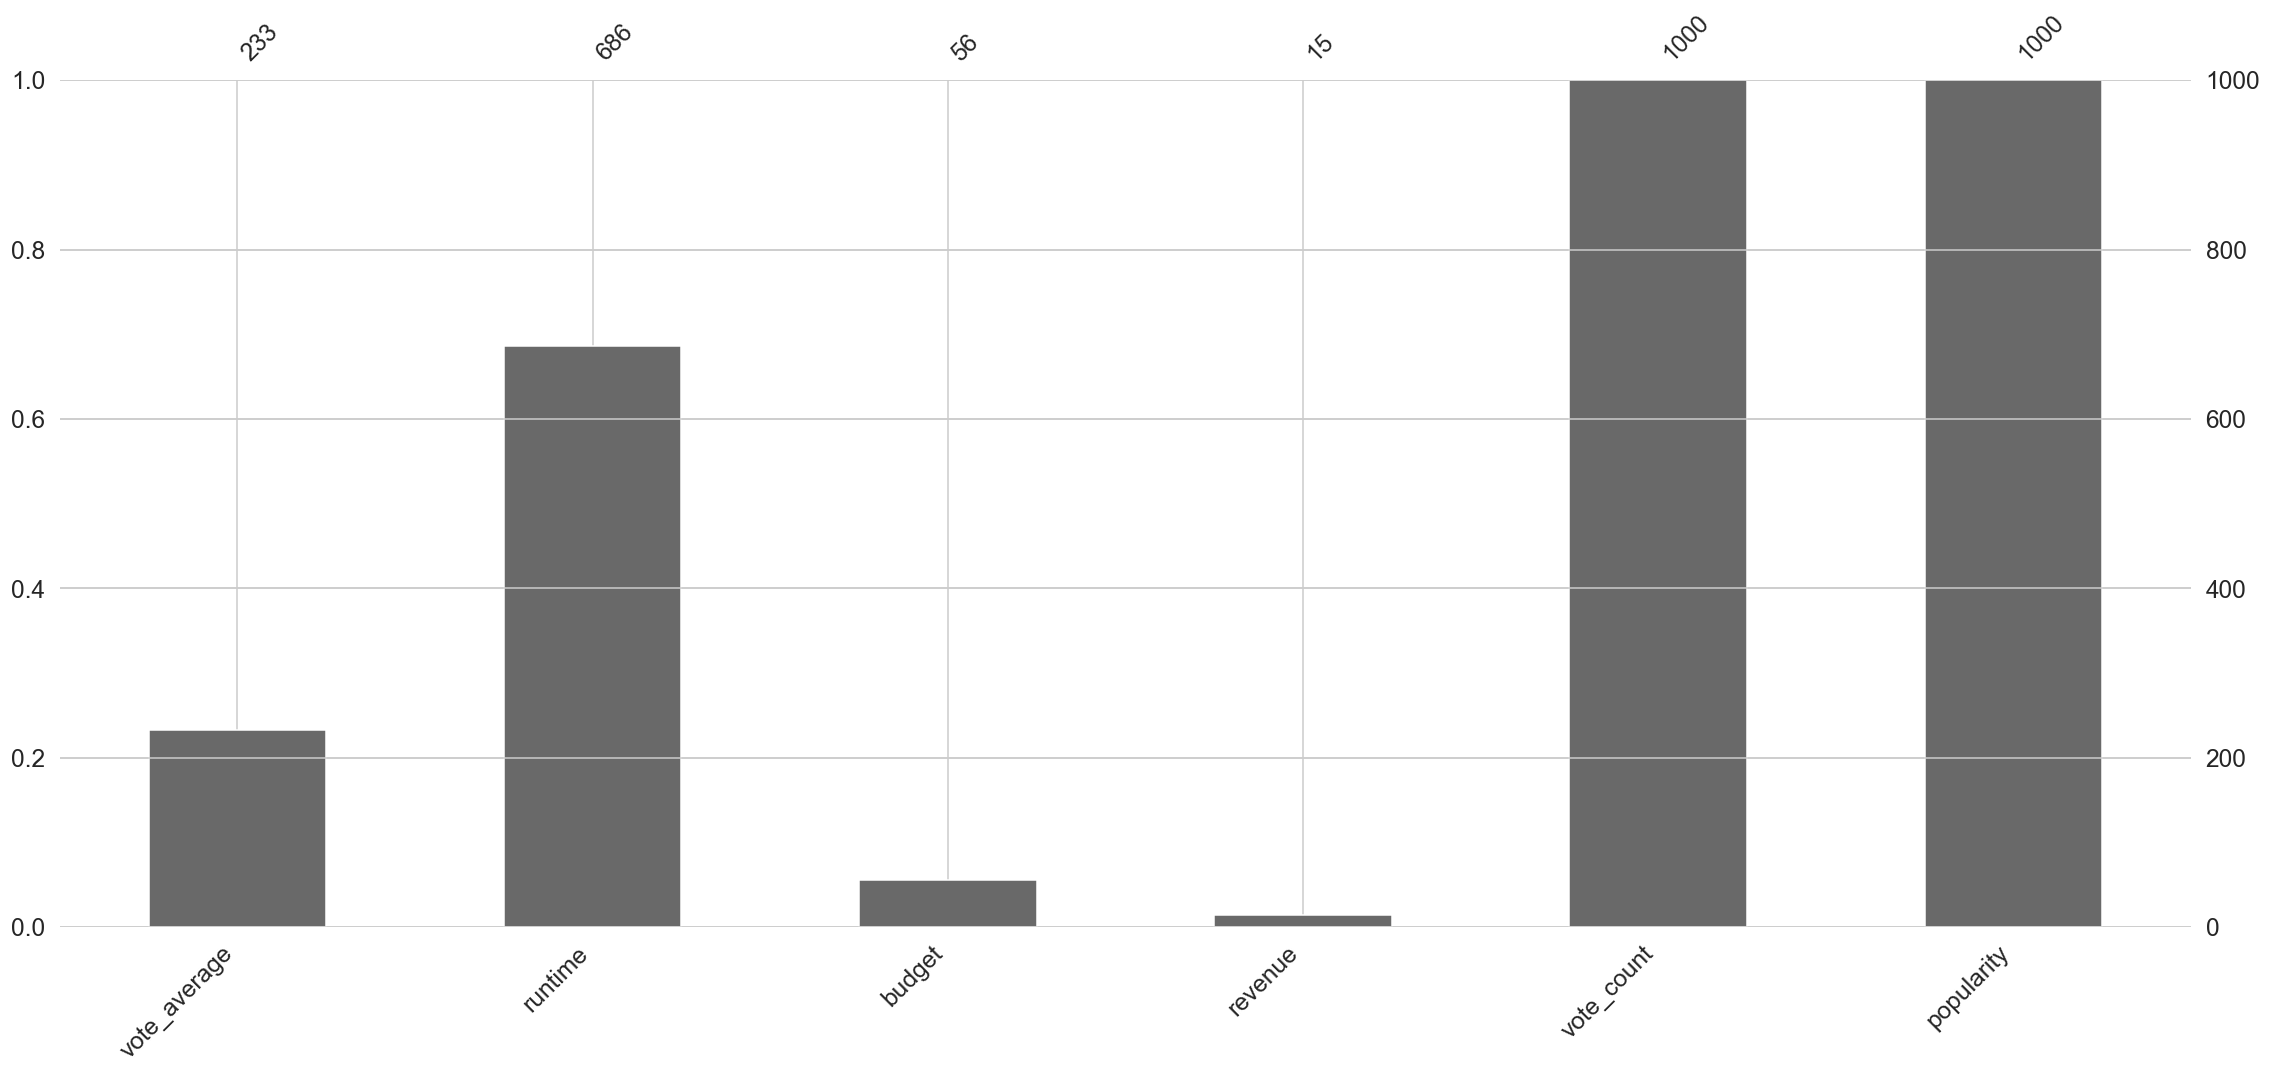

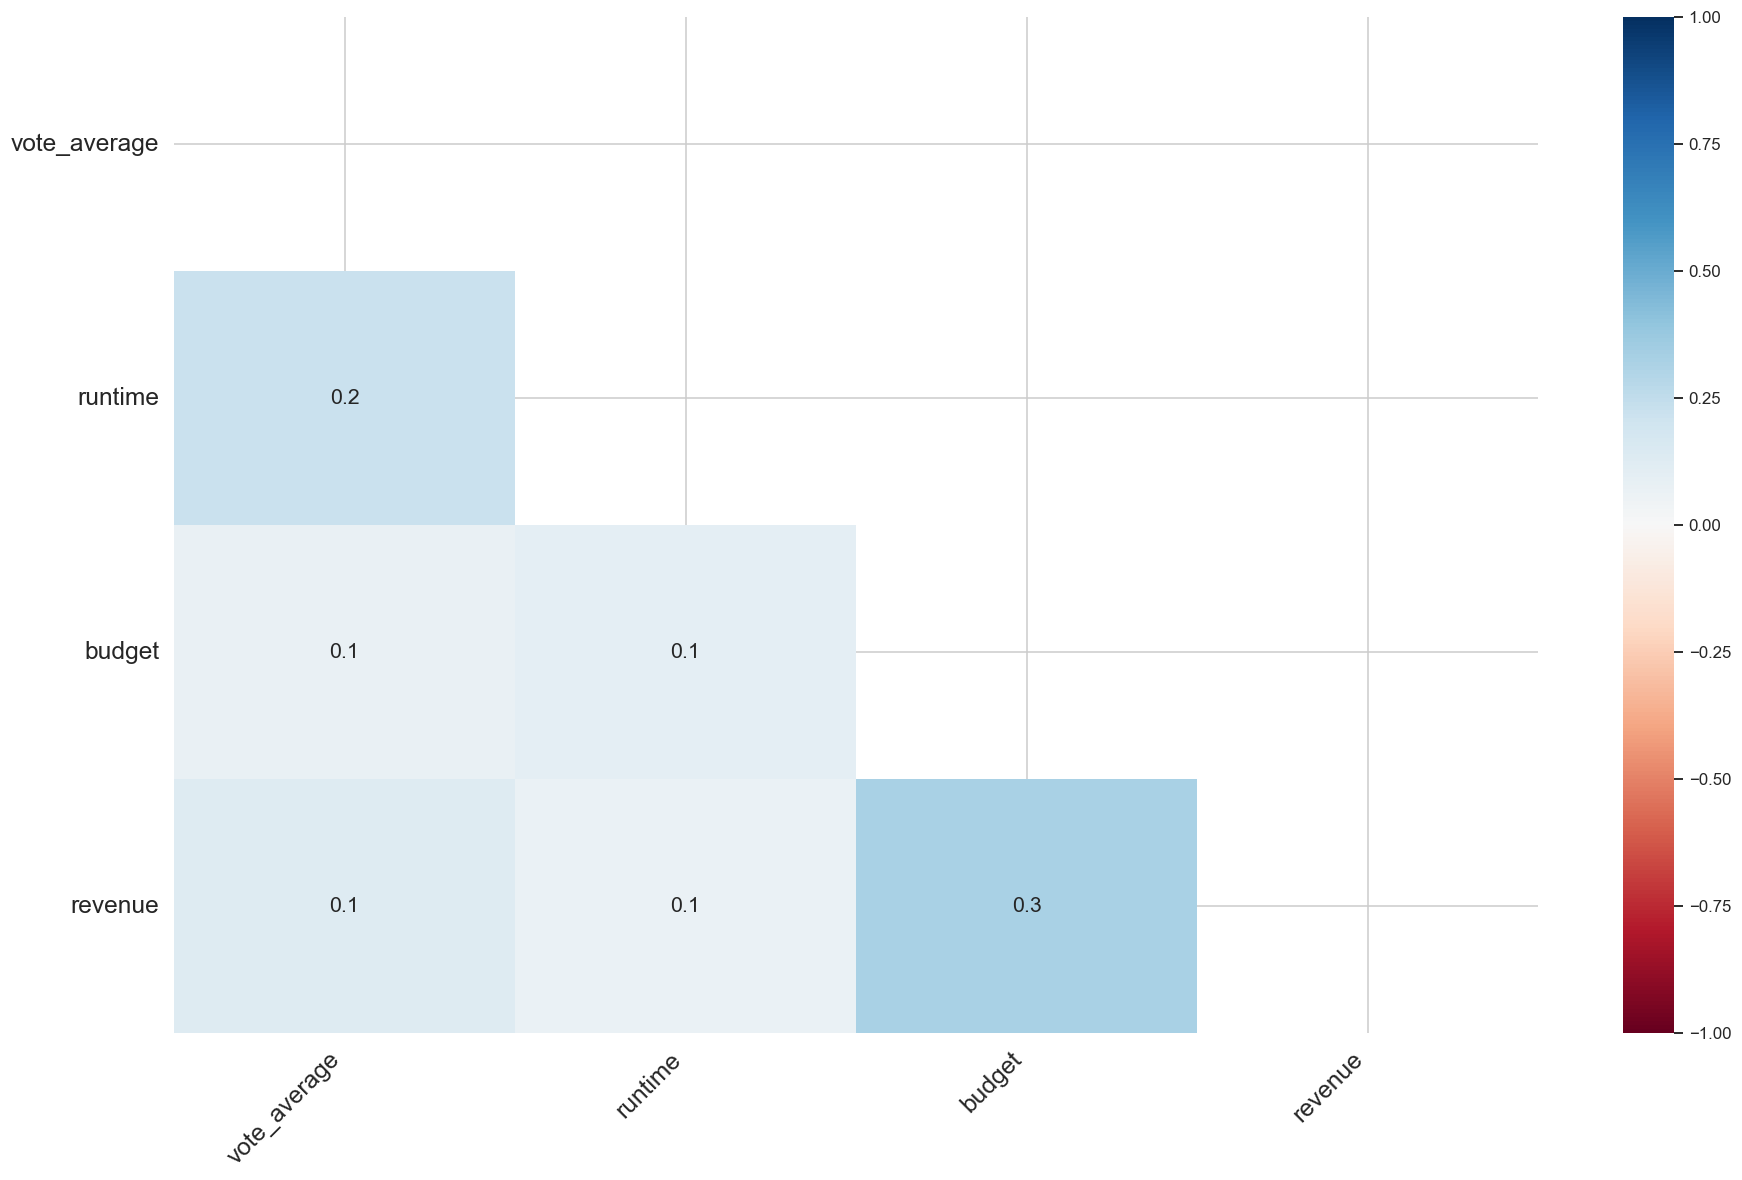

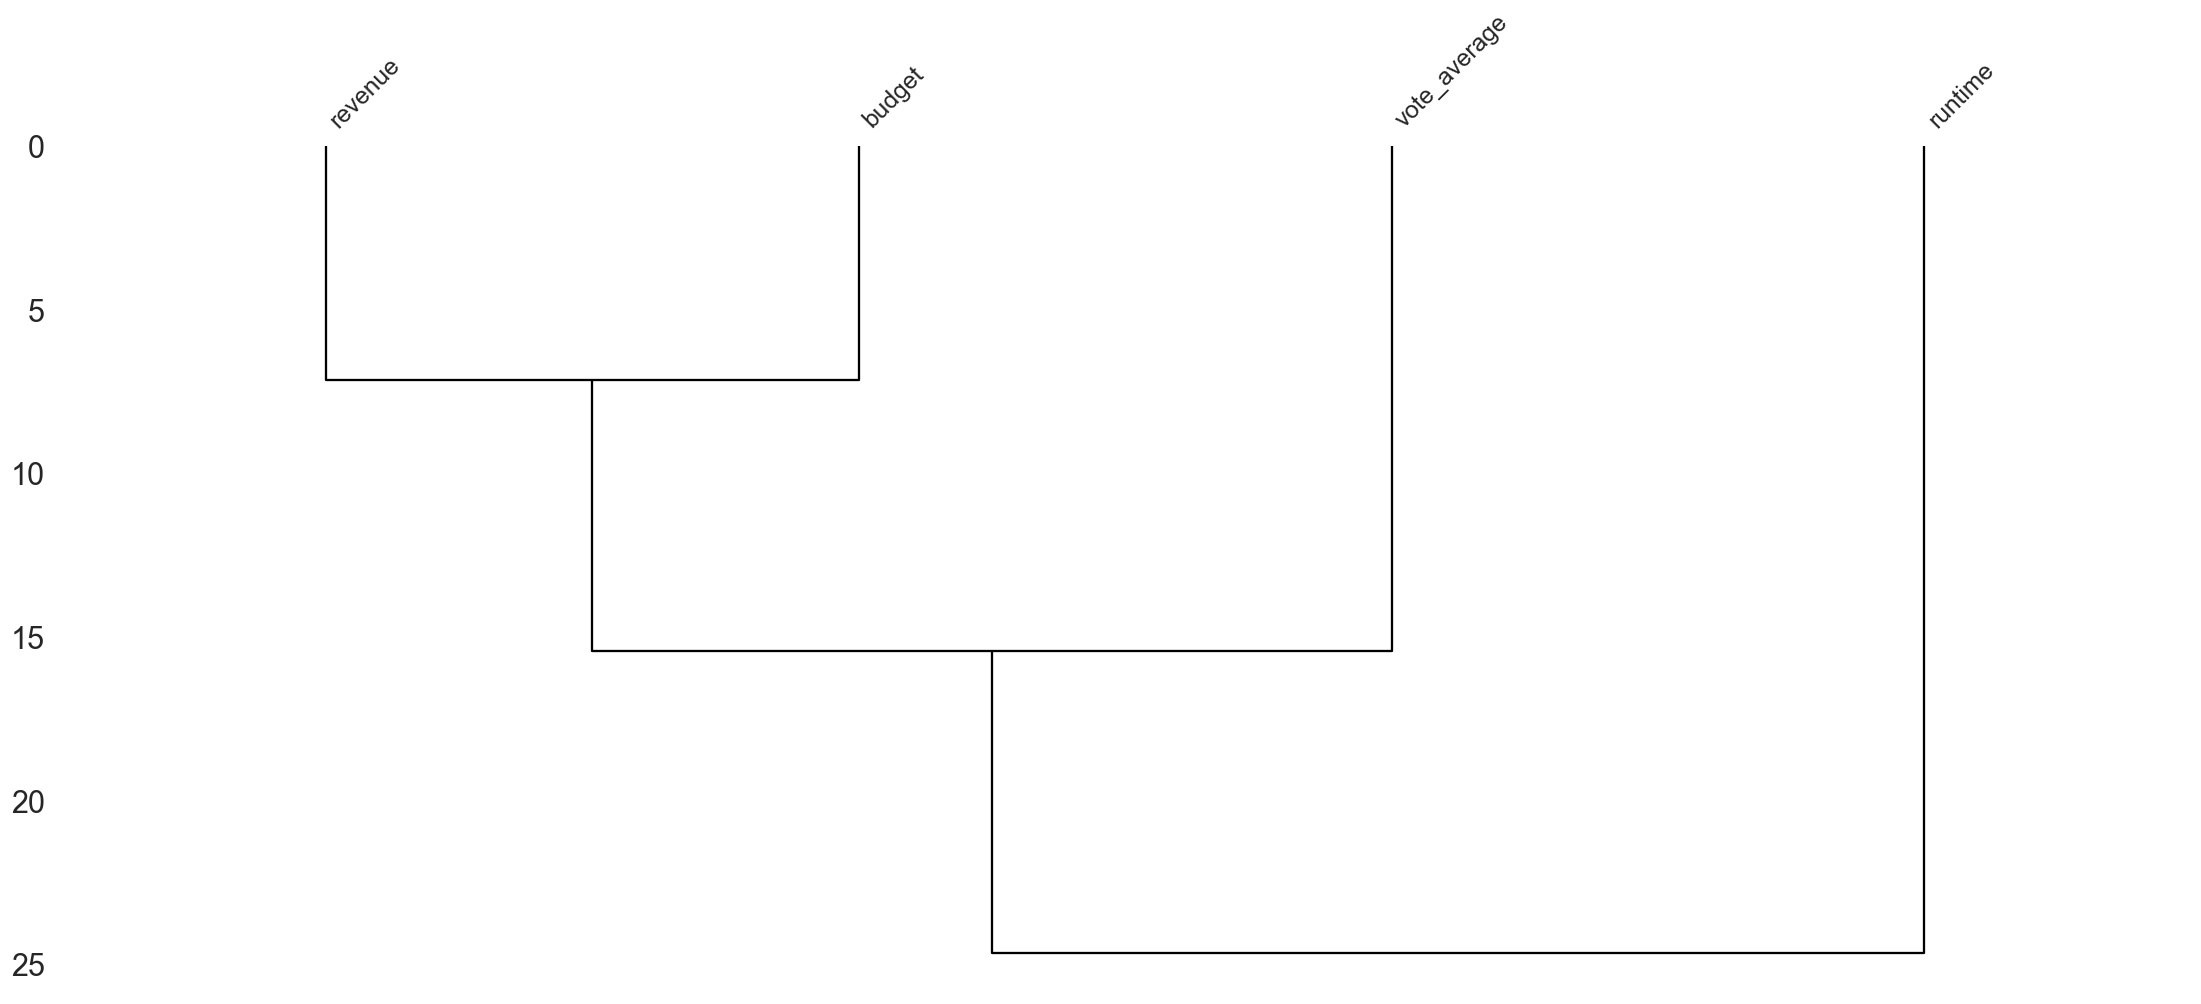

In [21]:
muestra_msno = df[num_foco].sample(1000, random_state=0)

msno.matrix(muestra_msno)
plt.show()

msno.bar(muestra_msno)
plt.show()

cols_con_nulos = [c for c in num_foco if muestra_msno[c].isna().any()]
msno.heatmap(muestra_msno[cols_con_nulos])
plt.show()

msno.dendrogram(muestra_msno[cols_con_nulos])
plt.show()

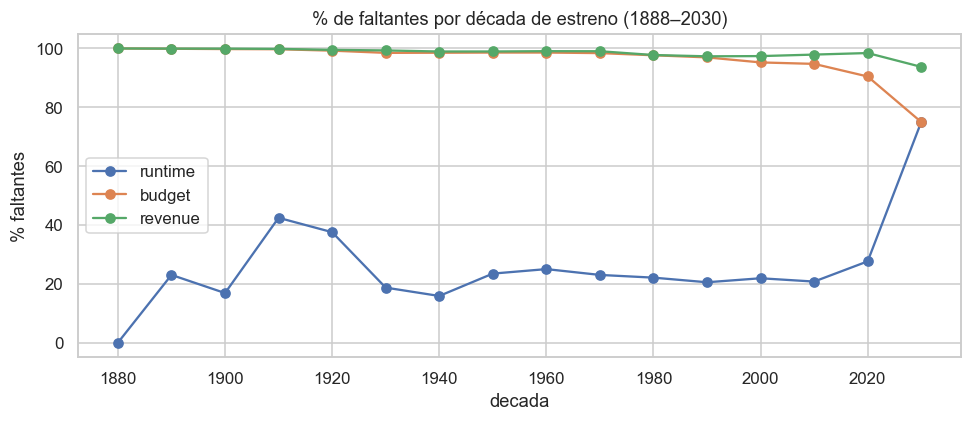

,runtime,budget,revenue
decada,,,
1880.0,0.000000,100.000000,100.000000
1890.0,23.028846,99.903846,99.951923
1900.0,16.862245,99.795918,99.948980
1910.0,42.444266,99.746362,99.859832
1920.0,37.556047,99.254815,99.526366
1930.0,18.713304,98.509560,99.337582
1940.0,15.873102,98.547097,98.971541
1950.0,23.476431,98.608394,98.981211
1960.0,25.004284,98.609649,99.086970


In [22]:
# % de faltantes por década de estreno (acotado a años plausibles 1888–2030;
# fechas fuera de ese rango son errores/placeholder de release_date, ver nota abajo)
anio = df["release_date"].dt.year
mask_plausible = anio.between(1888, 2030)
decada = (anio[mask_plausible] // 10 * 10)
tabla_decada = (df[mask_plausible].assign(decada=decada)
                  .groupby("decada")[["runtime", "budget", "revenue"]]
                  .apply(lambda g: g.isna().mean() * 100))

tabla_decada.plot(marker="o", figsize=(9, 4))
plt.ylabel("% faltantes")
plt.title("% de faltantes por década de estreno (1888–2030)")
plt.tight_layout()
plt.show()
tabla_decada

In [23]:
# Control de calidad: fechas de release_date fuera de rango plausible
anio = df["release_date"].dt.year
n_fut = int((anio > 2030).sum())
n_ant = int((anio < 1888).sum())
print(f"release_date con año > 2030 (futuras/erróneas): {n_fut}")
print(f"release_date con año < 1888 (previas al cine): {n_ant}")

release_date con año > 2030 (futuras/erróneas): 59
release_date con año < 1888 (previas al cine): 96


Antes de acotar, la agrupación por década incluía valores espurios (décadas 1800–1860 y 2030–2090) provenientes de fechas de carga erróneas o placeholder. Esas fechas implausibles (>2030 o <1888) se **excluyen de esta vista por década**; son fechas de carga erróneas que se eliminan en la etapa 5 (diagnóstico acá, en Clase 3; tratamiento en Clase 4).

In [24]:
# % de faltantes por género principal (primer género informado por película)
genero_principal = (genre_long.drop_duplicates(subset="id", keep="first")[["id", "genre"]]
                     .rename(columns={"genre": "genero_principal"}))
df_gp = df.merge(genero_principal, on="id", how="left")
tabla_genero = (df_gp.groupby("genero_principal")[["runtime", "budget", "revenue"]]
                     .apply(lambda g: g.isna().mean() * 100)
                     .sort_values("budget"))
tabla_genero

,runtime,budget,revenue
genero_principal,,,
Horror,19.508885,82.466434,96.782276
Science Fiction,19.234132,82.584368,96.266830
Thriller,23.039824,83.096780,95.673143
Mystery,23.617963,85.287793,95.989880
Adventure,21.002252,85.707583,91.741742
Fantasy,22.764228,86.849593,96.046748
Action,22.781031,87.347093,92.883645
Crime,23.367488,89.781224,95.740792
War,21.009448,90.303332,95.648931


`runtime` falta ~32% de forma pareja entre décadas y géneros → MCAR/MAR (no depende fuerte de la categoría). `budget` (~94%) y `revenue` (~98%) faltan de forma generalizada en todas las décadas/géneros → estructural (TMDB no reporta finanzas para la mayoría de los títulos); por superar 70% no se imputan.

**Mecanismos de faltante** (definiciones):
- **MCAR** (Missing Completely At Random): la ausencia es totalmente aleatoria, no depende de ninguna variable.
- **MAR** (Missing At Random): la ausencia depende de otras variables observadas, no del valor faltante en sí.
- **MNAR** (Missing Not At Random): la ausencia depende del propio valor no observado.
- **Estructural**: el dato no existe; no es un faltante real.

**Estrategia de tratamiento por columna** (regla general: <10% MCAR → borrar filas; 10–30% MCAR/MAR → imputación simple por mediana; >70% → no imputar):

| columna | % nulos | mecanismo | estrategia | justificación |
|---|---|---|---|---|
| revenue | 98.3 | estructural | no imputar | TMDB no reporta finanzas de la mayoría; imputar inventaría datos |
| budget | 94.1 | estructural | no imputar | ídem revenue: >70% |
| vote_average | 75.9 | estructural | no imputar | NaN = sin votos; un rating sin votos no es una calificación real |
| genres | 44.9 | estructural | categoría "sin dato" / excluir del análisis por género | no se imputa un género inexistente |
| runtime | 31.7 | MAR / MCAR | imputar por mediana (post-split) | ~30% (borde); mediana robusta a la asimetría, no distorsiona la forma |
| release_date | 23.7 | estructural | no imputar | la fecha no se inventa; los años implausibles se excluyen por rango |

vote_count y popularity no tienen nulos.

### 4.4 Outliers cuantitativos
Comparamos dos criterios: rango intercuartílico (IQR, robusto a asimetría) y 3 desvíos estándar (sensible a colas).

In [25]:
def contar_outliers(serie):
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf_iqr, lim_sup_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = ((s < lim_inf_iqr) | (s > lim_sup_iqr)).sum()

    media, desv = s.mean(), s.std()
    lim_inf_3s, lim_sup_3s = media - 3 * desv, media + 3 * desv
    n_3s = ((s < lim_inf_3s) | (s > lim_sup_3s)).sum()

    return pd.Series({
        "n_validos": len(s),
        "pct_outliers_iqr": round(100 * n_iqr / len(s), 2),
        "lim_iqr": (round(lim_inf_iqr, 1), round(lim_sup_iqr, 1)),
        "pct_outliers_3sigma": round(100 * n_3s / len(s), 2),
        "lim_3sigma": (round(lim_inf_3s, 1), round(lim_sup_3s, 1)),
    })

tabla_outliers = pd.DataFrame({c: contar_outliers(df[c]) for c in num_foco}).T
tabla_outliers

,n_validos,pct_outliers_iqr,lim_iqr,pct_outliers_3sigma,lim_3sigma
vote_average,360934,2.43,"(1.7, 10.5)",0.24,"(0.1, 12.2)"
runtime,1024989,1.24,"(-106.0, 214.0)",0.67,"(-128.5, 254.7)"
budget,88251,21.85,"(-149625.0, 249775.0)",1.42,"(-60228404.4, 68040976.2)"
revenue,25431,16.83,"(-18539017.8, 30901012.2)",1.54,"(-407823736.2, 479422887.6)"
vote_count,1499934,24.06,"(0.0, 0.0)",0.3,"(-817.8, 846.5)"
popularity,1499934,8.17,"(-1.0, 1.6)",0.3,"(-18.9, 20.8)"


In [26]:
# top-5 registros más extremos por columna (distancia absoluta a la mediana)
def top_extremos(col, n=5):
    s = df[[col, "title"]].dropna(subset=[col])
    mediana = s[col].median()
    s = s.assign(_dist=(s[col] - mediana).abs())
    return s.nlargest(n, "_dist")[["title", col]]

for col in num_foco:
    print(f"\nTop 5 extremos — {col}:")
    print(top_extremos(col).to_string(index=False))


Top 5 extremos — vote_average:
              title  vote_average
Fighting For A City           0.0
       Home Invader           0.0
              MMXII           0.0
        Winter Hunt           0.0
      The Boyfriend           0.0

Top 5 extremos — runtime:
                     title  runtime
      Modern Times Forever  14400.0
Svalbard minutt for minutt  13319.0
                 Cinématon  12480.0
              Beijing 2003   9000.0
   Untitled #125 (Hickory)   7200.0

Top 5 extremos — budget:
                                                           title      budget
                                                  In Whose Name? 999999999.0
                      #MagnumOpus Chapter I: The Song of Destiny 999999999.0
The Lord of the Rings: The Return of the King (Extended Edition) 940000000.0
                   ryan gosling der sutter logan pauls tissemand 900000000.0
                                                            Enea 888000000.0

Top 5 extremos — revenue:
      

                                                                                                                                                              title  popularity
                                                                                                                                                        Blue Beetle    2994.357
                                                                                                                                                       Gran Turismo    2680.593
A Female Boss with Big Tits and Her Cherry Boy Colleague Stay in the Same Room on a Business Trip - She Seduces Him for Fun and Makes Him Cum 10 Times - Yua Mikami    2020.286
                                                                                                                                                         The Nun II    1692.778
                                                                                                                        

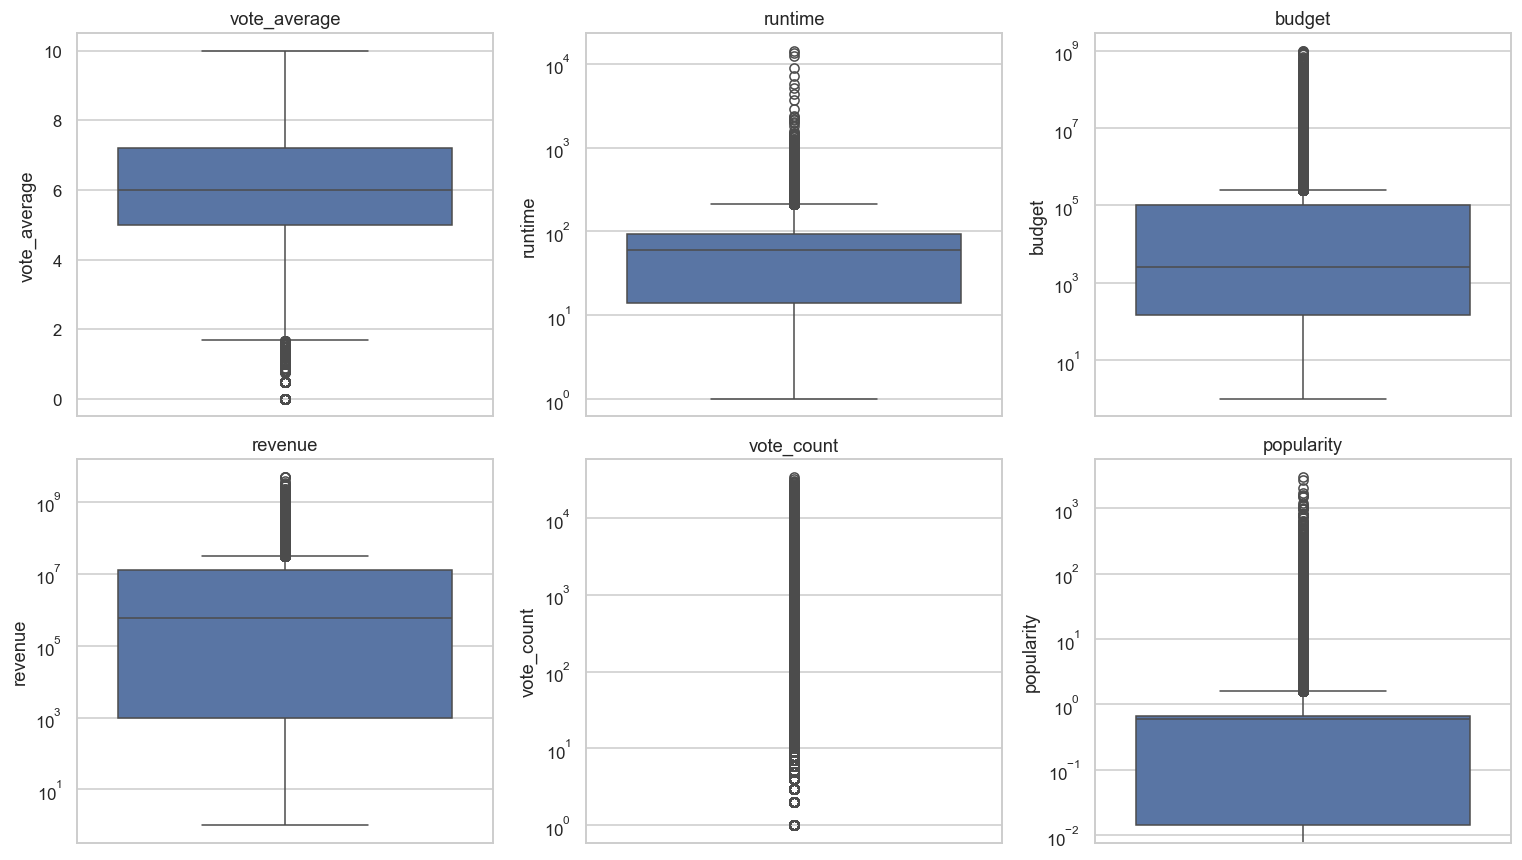

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
log_cols = {"budget", "revenue", "vote_count", "popularity", "runtime"}
for ax, col in zip(axes.flat, num_foco):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
    if col in log_cols:
        ax.set_yscale("log")
plt.tight_layout()
plt.show()

Los outliers son mayormente valores reales, no errores: títulos de recaudación y difusión muy altas explican budget 21.8%, revenue 16.8%, vote_count 24.1% y popularity 8.2% por IQR. Incluso los extremos de `runtime` (p. ej. 14400 min = 240 h) corresponden a obras reales de larguísima duración, no a errores. Los únicos errores de carga concretos están en la cola alta de `budget` y `revenue`: un puñado de filas con valores imposibles (presupuestos >460M o recaudaciones >3.000M) sobre títulos falsos, videojuegos o con fecha faltante/futura.

#### Inspección de los outliers sospechosos

Para separar errores de carga de extremos legítimos miramos los registros uno por uno. La firma de un error de carga es un valor imposible junto a metadata incoherente: `vote_count` en 0, fecha faltante o futura, y un título que no es una película (videojuego, secuela inexistente, broma). Los verdaderos extremos, en cambio, tienen metadata consistente.

In [28]:
# Presupuestos imposibles: por encima del mayor presupuesto real documentado (~460M, Avatar 2)
cols_insp = ["title", "release_date", "vote_count", "budget", "revenue", "runtime"]
budget_sosp = (df.loc[df["budget"] > 460_000_000, cols_insp]
                 .sort_values("budget", ascending=False))
print(f"budget > 460M: {len(budget_sosp)} filas")
display(budget_sosp)

budget > 460M: 27 filas


,title,release_date,vote_count,budget,revenue,runtime
712908,#MagnumOpus Chapter I: The Song of Destiny,2060-07-23,0,999999999.0,NaN,NaN
398880,In Whose Name?,NaT,0,999999999.0,NaN,NaN
742720,The Lord of the Rings: The Return of the King ...,NaT,0,940000000.0,1.148000e+08,263.0
374170,ryan gosling der sutter logan pauls tissemand,NaT,0,900000000.0,1.600000e+01,NaN
1238223,Enea,2023-09-21,0,888000000.0,NaN,115.0
238168,Batman v Superman: Dawn of Justice: Ultimate E...,2016-06-28,1,874362803.0,2.500000e+08,182.0
798949,ETERNIA: TWILIGHT OF STARS,2027-03-12,0,873000000.0,NaN,NaN
749767,Fifa World Cup 2026 Round of 16 USA vs Belgium,NaT,0,800000000.0,1.300000e+06,90.0
842736,Shadow the Hedgehog,NaT,0,800000000.0,NaN,NaN
444137,Adventures in Bora Bora,2023-08-23,0,800000000.0,3.000000e+09,5.0


In [29]:
# Recaudaciones imposibles: por encima de la mayor recaudación real documentada (~2.9B, Avatar 2)
revenue_sosp = (df.loc[df["revenue"] > 3_000_000_000, cols_insp]
                  .sort_values("revenue", ascending=False))
print(f"revenue > 3.000M: {len(revenue_sosp)} filas")
display(revenue_sosp)

revenue > 3.000M: 7 filas


,title,release_date,vote_count,budget,revenue,runtime
471179,babben: the movie,NaT,0,100.0,5.000000e+09,999.0
650046,Han Sur Lesses,2026-04-23,0,500.0,5.000000e+09,NaN
678051,In the Virtual End (Linkin Park HL2 music video),2009-11-02,0,1.0,5.000000e+09,4.0
773028,Juliet and Romeo - 1231 ☆*: .｡. o(≧▽≦)o .｡.:*☆...,1800-01-01,0,1.0,5.000000e+09,NaN
236454,Marvel's Spider-Man,2018-09-07,1,100000000.0,3.800000e+09,999.0
666782,Macbeth's Ambition,2026-01-02,0,10000000.0,3.477780e+09,82.0
335658,Red Dead Redemption II,NaT,1,540000000.0,3.100000e+09,NaN


In [30]:
# Registro de runtime máximo (14400 min = 240 h)
display(df.loc[df["runtime"] >= 14400, ["title", "release_date", "vote_count", "runtime", "overview"]])

,title,release_date,vote_count,runtime,overview
219795,Modern Times Forever,2011-03-23,2,14400.0,"The film shows centuries of decay, compressed ..."


En las dos tablas de arriba se ve la firma del error de carga: presupuestos de 999.999.999 o recaudaciones de 5.000M sobre títulos como *Avatar 4/5*, *Red Dead Redemption II* (videojuego), *Fifa World Cup 2026* o *Shadow the Hedgehog*, casi todos con `vote_count` en 0 y fecha faltante o futura. Son ~34 filas; el diagnóstico queda acá y estos errores de carga concretos se eliminan en la etapa 5 (Clase 4).

El caso `runtime = 14400` (240 h) se analizó aparte y **no** es un error. A diferencia de los anteriores, su registro tiene metadata coherente —fecha válida (2011), `vote_count > 0` y un `overview` real sobre el edificio Stora Enso de Helsinki—, así que no tiene la firma del error de carga. Además el título corresponde a *Modern Times Forever*, una obra de video-arte documentada de 240 h continuas: el valor coincide con la duración real de la obra. Por eso queda como outlier legítimo (dato real de larguísima duración), no como error.

### 4.5 Entropía de Shannon (géneros)
H mide la diversidad de la distribución de géneros; H_max=log2(k) es el máximo posible con k categorías equiprobables.

H = 3.660 bits, H_max = 4.248 bits (k=19), H/H_max = 0.862


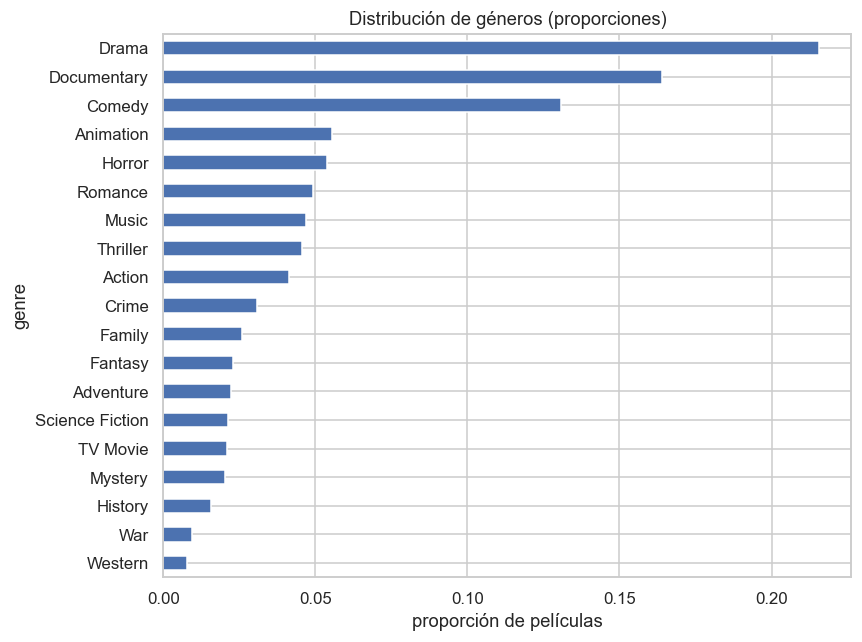

In [31]:
proporciones = genre_long["genre"].value_counts(normalize=True)
H = entropy(proporciones, base=2)
k = len(proporciones)
H_max = np.log2(k)
print(f"H = {H:.3f} bits, H_max = {H_max:.3f} bits (k={k}), H/H_max = {H / H_max:.3f}")

plt.figure(figsize=(8, 6))
proporciones.sort_values().plot(kind="barh")
plt.xlabel("proporción de películas")
plt.title("Distribución de géneros (proporciones)")
plt.tight_layout()
plt.show()

H/H_max = 0.862 (k=19): la diversidad de géneros es alta, sin uno dominante extremo. Drama, Documentary y Comedy concentran la mayor proporción de películas. La entropía de Shannon (y el índice de Gini) también es la métrica con que se detecta el desbalance de clases, tema que retomamos sobre el target en la preparación (5.11).

## 5. Preparación de datos (Clase 4)

Registramos el tratamiento de las 15 columnas todavía sin procesar (identificadores, categóricas, multivaluadas, texto y URLs). Las transformaciones se tejen en las subsecciones de abajo y las columnas originales se eliminan en el dataset final (5.13).

| Grupo | Columna | %null | Decisión | Variables nuevas |
|---|---|---|---|---|
| A | `id` | 0 | Conservar como clave | — |
| A | `title` | 0 | `title_length` y eliminar | `title_length` |
| A | `original_title` | 0 | Eliminar | — |
| A | `imdb_id` | 54.2 | Eliminar | — |
| B | `homepage` | 89.8 | indicador → eliminar | `tiene_homepage` |
| B | `backdrop_path` | 75.6 | indicador → eliminar | `tiene_backdrop` |
| B | `poster_path` | 36.5 | indicador → eliminar | `tiene_poster` |
| C | `overview` | 23.3 | indicador + largo → eliminar | `tiene_overview`, `len_overview` |
| C | `tagline` | 86.0 | indicador + largo → eliminar | `tiene_tagline`, `len_tagline` |
| D | `status` | 0 | OHE 3 vías → eliminar | `status_released`, `status_in_production`, `status_otros` |
| D | `adult` | 0 | `astype(int)` | `adult` (int) |
| E | `original_language` | 0 | OHE top-10 + otros (fit train) → eliminar | `lang_*` |
| F | `spoken_languages` | 47.5 | `n_idiomas` + `tiene_idiomas` + multi-hot top-15 + otros → eliminar | `n_idiomas`, `tiene_idiomas`, `lang_hab_*` |
| F | `production_countries` | 49.4 | `n_paises` + `tiene_paises` + multi-hot top-15 + otros → eliminar | `n_paises`, `tiene_paises`, `pais_*` |
| F | `production_companies` | 58.0 | `n_companias` + `tiene_companias` + multi-hot top-15 + otros → eliminar | `n_companias`, `tiene_companias`, `comp_*` |
| F | `keywords` | 75.7 | `n_keywords` + `tiene_keywords` → eliminar | `n_keywords`, `tiene_keywords` |

El corte top-15 de idiomas/países es un "sweet spot": en 2.6 el umbral ≥1% de apariciones cayó en ~14 idiomas y ~20 países, así que 15 queda cerca del codo de la curva de cobertura. `production_companies` usa el mismo top-15, aunque por su cola larguísima (la más frecuente llega a 0.40%) la mayoría de las filas cae en "otros". Los rankings top-N se aprenden solo en train (anti-leakage) y lo no visto en test cae en "otros".

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### 5.1 Split train/test

El split va primero, antes de imputar o tratar outliers: así ningún estadístico (mediana, percentiles) se calcula viendo datos de test, evitando fuga de información. Para la etapa de preparación (Clase 5) tratamos `popularity` como **target de clasificación**: la discretizamos por umbrales de dominio (`<1` baja, `1-10` media, `≥10` alta), lo que produce clases desbalanceadas, y estratificamos el split por esas clases (`stratify`).

In [33]:
df["popularity_cat"] = pd.cut(df["popularity"], bins=[-np.inf, 1, 10, np.inf],
                              labels=["baja", "media", "alta"])
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42,
                                     stratify=df["popularity_cat"])
print(f"train: {train_df.shape[0]} filas | test: {test_df.shape[0]} filas")
print("Distribución del target (proporción, train):")
print(train_df["popularity_cat"].value_counts(normalize=True).round(3).to_string())

train: 1199947 filas | test: 299987 filas
Distribución del target (proporción, train):
popularity_cat
baja     0.831
media    0.158
alta     0.011


### 5.2 Limpieza de errores de carga

Antes de imputar, eliminamos los registros con valores imposibles detectados en la Sección 4.4: presupuestos por encima del récord real documentado (~460M) o recaudaciones por encima de ~2.900M (sobre títulos falsos, videojuegos o secuelas inexistentes, sin votos), y los registros con fecha imposible (año > 2030 o < 1888). Son errores de carga, no outliers legítimos, así que se descartan (eliminación de filas). El criterio es un umbral de dominio (no aprendido de los datos), por lo que aplicarlo por igual a train y test no introduce fuga de información.

In [34]:
# Errores de carga: valores imposibles (budget/revenue por encima del récord real documentado
# ~460M / ~2.9B) o fecha imposible (año > 2030 o < 1888). Las fechas faltantes (NaT) no se eliminan.
anio_tr = train_df["release_date"].dt.year
anio_te = test_df["release_date"].dt.year
err_train = ((train_df["budget"] > 460_000_000) | (train_df["revenue"] > 3_000_000_000)
             | (anio_tr > 2030) | (anio_tr < 1888))
err_test  = ((test_df["budget"]  > 460_000_000) | (test_df["revenue"]  > 3_000_000_000)
             | (anio_te > 2030) | (anio_te < 1888))
print(f"Errores de carga eliminados -> train: {int(err_train.sum())} | test: {int(err_test.sum())}")
train_df = train_df[~err_train].copy()
test_df  = test_df[~err_test].copy()
print(f"Tamaños tras limpieza -> train: {len(train_df)} | test: {len(test_df)}")

Errores de carga eliminados -> train: 150 | test: 35


Tamaños tras limpieza -> train: 1199797 | test: 299952


### 5.3 Imputación (fit en train)

`runtime` (~31.7% nulo, MCAR/MAR) es el único que se imputa, con la mediana aprendida en train.

Los demás superan el 70% de nulos y no se imputan (imputar fabricaría la mayoría del dato), pero por mecanismos distintos:
- **budget (94.1%) y revenue (98.3%) → estructural:** el dato no existe para la mayoría del catálogo (TMDB reporta finanzas casi solo de estrenos comerciales), así que imputar inventaría valores. Se **reemplaza** la columna cruda por un **indicador binario de presencia** (`tiene_budget`/`tiene_revenue`): con 94-98% de faltantes la columna no aporta como feature, así que se elimina y se conserva solo la marca de si el dato está informado.
- **vote_average (75.9%) → estructural:** es NaN exactamente cuando `vote_count == 0` (sin votos no hay promedio). No se imputa (0 sería una nota válida, no un faltante) ni se le agrega flag, porque `vote_count` ya codifica esa ausencia.
- **URLs y texto de alto faltante → indicador de presencia:** homepage, backdrop_path, poster_path, overview y tagline se reemplazan por un binario `tiene_*` (el dato falta de forma estructural); las columnas originales se eliminan en el dataset final (5.13).

In [35]:
runtime_mediana_train = train_df["runtime"].median()

train_df = train_df.copy()
test_df = test_df.copy()
train_df["runtime_imp"] = train_df["runtime"].fillna(runtime_mediana_train)
test_df["runtime_imp"] = test_df["runtime"].fillna(runtime_mediana_train)

print(f"Mediana de runtime aprendida en train: {runtime_mediana_train:.1f} min")
print(f"Nulos runtime train: {train_df['runtime'].isna().sum()} -> {train_df['runtime_imp'].isna().sum()}")
print(f"Nulos runtime test:  {test_df['runtime'].isna().sum()} -> {test_df['runtime_imp'].isna().sum()}")

Mediana de runtime aprendida en train: 60.0 min
Nulos runtime train: 380160 -> 0
Nulos runtime test:  94716 -> 0


In [36]:
# Indicador de presencia para budget/revenue (faltante estructural): el dato no existe para la
# mayoría del catálogo; conservamos el crudo y marcamos si está informado.
# vote_average NO lleva flag: su faltante ya está codificado por vote_count == 0.
for col in ["budget", "revenue"]:
    train_df[f"tiene_{col}"] = train_df[col].notna().astype(int)
    test_df[f"tiene_{col}"]  = test_df[col].notna().astype(int)
print("Flags creados:", [f"tiene_{c}" for c in ["budget", "revenue"]])
print("Proporción con dato (train):")
print(train_df[["tiene_budget", "tiene_revenue"]].mean().round(3).to_string())

# Las columnas crudas se reemplazan por el indicador: se eliminan.
train_df = train_df.drop(columns=["budget", "revenue"])
test_df  = test_df.drop(columns=["budget", "revenue"])
print("Columnas budget/revenue eliminadas (reemplazadas por indicadores).")

# Indicadores de presencia para URLs (B) y texto libre (C): faltante estructural; conservamos solo
# la marca de si el dato está informado (las columnas originales se dropean en 5.13).
ind_cols = {"homepage": "homepage", "backdrop_path": "backdrop", "poster_path": "poster",
            "overview": "overview", "tagline": "tagline"}
for col, nombre in ind_cols.items():
    train_df[f"tiene_{nombre}"] = train_df[col].notna().astype(int)
    test_df[f"tiene_{nombre}"]  = test_df[col].notna().astype(int)
print("Proporción con dato (train) para URLs y texto:")
print(train_df[["tiene_homepage", "tiene_backdrop", "tiene_poster",
                "tiene_overview", "tiene_tagline"]].mean().round(3).to_string())

Flags creados: ['tiene_budget', 'tiene_revenue']
Proporción con dato (train):
tiene_budget     0.059
tiene_revenue    0.017


Columnas budget/revenue eliminadas (reemplazadas por indicadores).


Proporción con dato (train) para URLs y texto:
tiene_homepage    0.102
tiene_backdrop    0.244
tiene_poster      0.635
tiene_overview    0.767
tiene_tagline     0.140


Al imputar solo ~32% de los valores, el histograma conserva la forma general y agrega masa puntual en la mediana de train, sin distorsionar la distribución global.

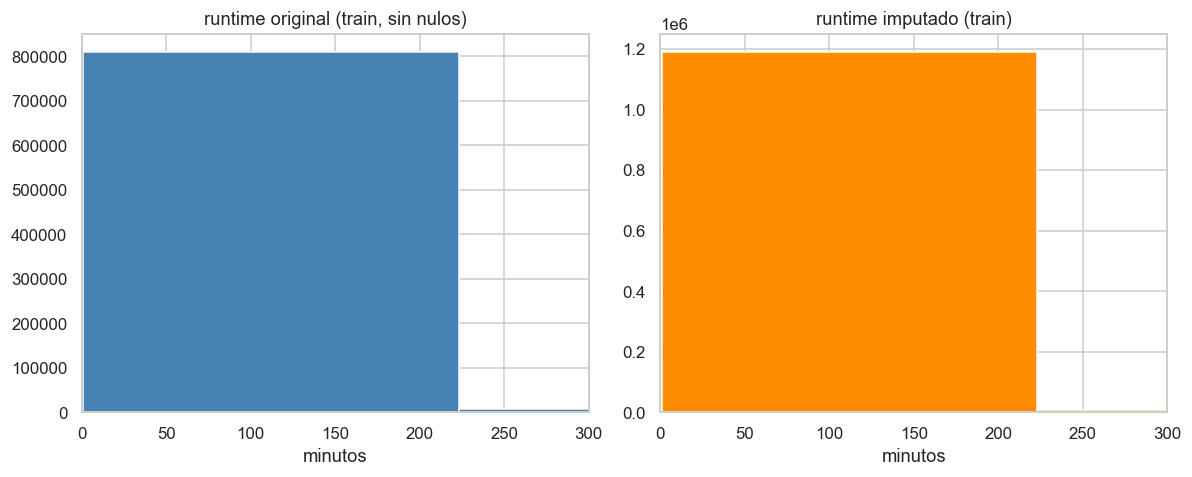

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(train_df["runtime"].dropna(), bins=60, color="steelblue")
axes[0].set_title("runtime original (train, sin nulos)")
axes[1].hist(train_df["runtime_imp"], bins=60, color="darkorange")
axes[1].set_title("runtime imputado (train)")
for ax in axes:
    ax.set_xlim(0, 300)
    ax.set_xlabel("minutos")
plt.tight_layout()
plt.show()

### 5.4 Tratamiento de outliers

Solo tratamos las continuas que sobreviven como features: `runtime` con capping percentil 1-99 (límites de train) y `vote_count` con log1p para comprimir su cola. `budget`/`revenue` se reemplazaron por indicadores en 5.3; `vote_average` y `popularity` se discretizan (5.6), y la discretización por cuantiles ya contiene sus extremos.

In [38]:
# Outliers de las continuas que quedan como features: runtime (capping p1-p99) y vote_count (log1p).
# vote_average y popularity se discretizan (no se capean); budget/revenue ya se reemplazaron por indicadores.
lo_rt, hi_rt = train_df["runtime_imp"].quantile([0.01, 0.99])
train_df["runtime_cap"] = train_df["runtime_imp"].clip(lo_rt, hi_rt)
test_df["runtime_cap"]  = test_df["runtime_imp"].clip(lo_rt, hi_rt)

train_df["vote_count_log"] = np.log1p(train_df["vote_count"])
test_df["vote_count_log"]  = np.log1p(test_df["vote_count"])
print(f"runtime: límites de capping (train p1-p99) = [{lo_rt:.0f}, {hi_rt:.0f}] min")
print("vote_count transformado con log1p")

runtime: límites de capping (train p1-p99) = [1, 202] min
vote_count transformado con log1p


El log1p comprime la cola larga de `vote_count` sin descartar observaciones (los ceros —sin votos— quedan en log1p(0)=0).

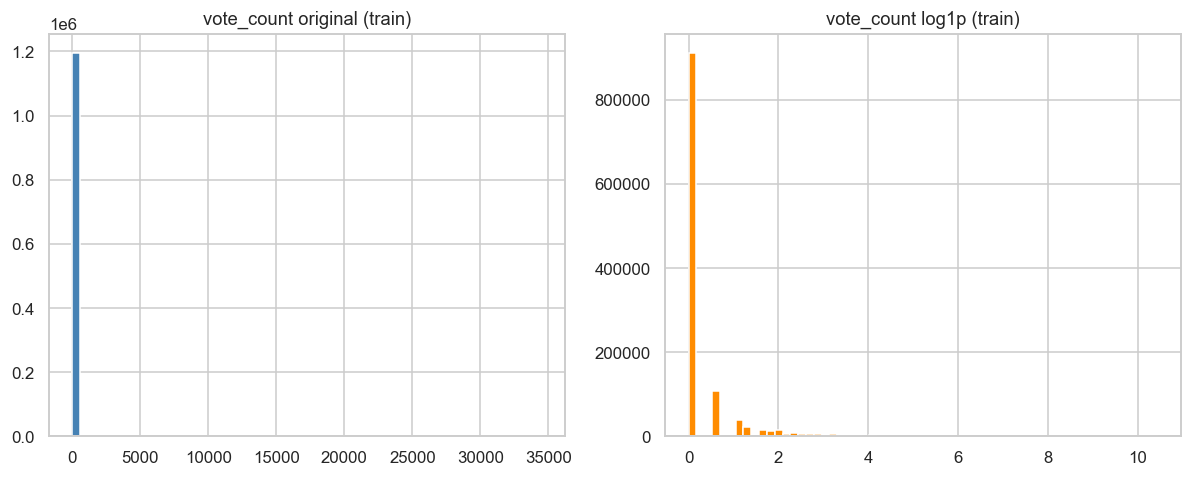

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(train_df["vote_count"].dropna(), bins=60, color="steelblue")
axes[0].set_title("vote_count original (train)")
axes[1].hist(train_df["vote_count_log"].dropna(), bins=60, color="darkorange")
axes[1].set_title("vote_count log1p (train)")
plt.tight_layout()
plt.show()

### 5.5 Creación de features

Derivamos variables sobre los datos ya tratados: temporales desde `release_date` limpio, `n_generos`, el largo de `title`/`overview`/`tagline` (`title_length`, `len_*`) y el conteo de ítems de las multivaluadas (`n_idiomas`, `n_paises`, `n_companias`, `n_keywords`) con su indicador `tiene_*`. No derivamos nada de `popularity` (es el target). Se descarta `roi = revenue/budget`: `budget`/`revenue` se eliminaron en 5.3 y tendría demasiados faltantes.

In [40]:
for d in (train_df, test_df):
    d["anio"] = d["release_date"].dt.year
    d["decada"] = (d["anio"] // 10 * 10)
    d["mes"] = d["release_date"].dt.month
    d["n_generos"] = d["genres"].fillna("").apply(lambda s: len([g for g in s.split(", ") if g]))
    # Largo de texto (A, C): 0 cuando el campo está vacío
    d["title_length"] = d["title"].fillna("").str.len()
    d["len_overview"] = d["overview"].fillna("").str.len()
    d["len_tagline"] = d["tagline"].fillna("").str.len()
    # Conteo de ítems en las multivaluadas (F) + indicador de presencia
    for col, nombre in [("spoken_languages", "idiomas"), ("production_countries", "paises"),
                        ("production_companies", "companias"), ("keywords", "keywords")]:
        d[f"n_{nombre}"] = d[col].fillna("").apply(lambda s: len([t for t in s.split(", ") if t]))
        d[f"tiene_{nombre}"] = (d[f"n_{nombre}"] > 0).astype(int)

feats_show = ["anio", "decada", "mes", "n_generos", "title_length", "len_overview",
              "len_tagline", "n_idiomas", "n_paises", "n_companias", "n_keywords"]
print("Features nuevos (train):")
print(train_df[feats_show].describe().round(2).to_string())

Features nuevos (train):


            anio     decada        mes   n_generos  title_length  len_overview  len_tagline   n_idiomas    n_paises  n_companias  n_keywords
count  915778.00  915778.00  915778.00  1199797.00    1199797.00    1199797.00   1199797.00  1199797.00  1199797.00   1199797.00  1199797.00
mean     2001.51    1997.14       5.88        0.84         20.26        202.83         6.26        0.58        0.55         0.59        0.79
std        26.44      26.70       3.80        0.97         14.79        213.72        20.11        0.63        0.70         0.95        2.25
min      1888.00    1880.00       1.00        0.00          0.00          0.00         0.00        0.00        0.00         0.00        0.00
25%      1992.00    1990.00       2.00        0.00         11.00         20.00         0.00        0.00        0.00         0.00        0.00
50%      2012.00    2010.00       6.00        1.00         17.00        145.00         0.00        1.00        1.00         0.00        0.00
75%      2020

### 5.6 Discretización

El **target** `popularity_cat` se discretizó por umbrales de dominio (5.1) generando clases desbalanceadas. Como **feature** discretizamos `vote_average` con `qcut` (igual frecuencia, pensada para EDA); los títulos sin votos quedan en su propia categoría. `pd.cut` (igual amplitud) y `KBinsDiscretizer(encode='ordinal')` son alternativas (esta última, lista para ML).

In [41]:
# qcut en train (igual frecuencia); los cortes se reutilizan en test (transform).
_, bins_va = pd.qcut(train_df["vote_average"].dropna(), q=4, retbins=True, duplicates="drop")
bins_va = bins_va.copy()
bins_va[0], bins_va[-1] = -np.inf, np.inf
labels_va = ["bajo", "medio-bajo", "medio-alto", "alto"][: len(bins_va) - 1]

for d in (train_df, test_df):
    cat = pd.cut(d["vote_average"], bins=bins_va, labels=labels_va, include_lowest=True)
    d["vote_average_cat"] = cat.cat.add_categories("sin votos").fillna("sin votos")

print("Distribución de vote_average_cat (train):")
print(train_df["vote_average_cat"].value_counts().to_string())

Distribución de vote_average_cat (train):
vote_average_cat
sin votos     911383
bajo           82671
alto           71189
medio-alto     70010
medio-bajo     64544


### 5.7 Codificación

Con 19 géneros (baja cardinalidad) el one-hot es apropiado. Como una película puede tener varios géneros (relación 1-a-muchos), se usa multi-hot a nivel película; el género principal (primero de la lista) se codifica además con OneHotEncoder. Los títulos sin género (44.9%, faltante estructural) se marcan con una categoría propia **"SIN_GÉNERO"** en lugar de excluirlos.

Con el mismo criterio codificamos el resto de categóricas: `status` (OHE 3 vías: Released, In Production, otros), `adult` (a entero), `original_language` (OHE top-10 + "otros") y las multivaluadas `spoken_languages`/`production_countries`/`production_companies` (multi-hot de las 15 categorías más frecuentes + "otros"). Los rankings top-N se aprenden solo en train y lo no visto en test cae en "otros".

In [42]:
genre_multihot = df.set_index("id")["genres"].str.get_dummies(", ").add_prefix("gen_")
print("shape multi-hot:", genre_multihot.shape)
genre_multihot.head()

shape multi-hot: (1499934, 19)


,gen_Action,gen_Adventure,gen_Animation,gen_Comedy,gen_Crime,gen_Documentary,gen_Drama,gen_Family,gen_Fantasy,gen_History,gen_Horror,gen_Music,gen_Mystery,gen_Romance,gen_Science Fiction,gen_TV Movie,gen_Thriller,gen_War,gen_Western
id,,,,,,,,,,,,,,,,,,,
27205,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
157336,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
155,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0
19995,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
24428,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [43]:
genero_principal_ohe = (df[["id"]].merge(
        genre_long.drop_duplicates(subset="id", keep="first")[["id", "genre"]],
        on="id", how="left")
    .rename(columns={"genre": "genero_principal"}))
genero_principal_ohe["genero_principal"] = genero_principal_ohe["genero_principal"].fillna("SIN_GÉNERO")

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_matrix = ohe.fit_transform(genero_principal_ohe[["genero_principal"]])
print("shape OneHot género principal:", ohe_matrix.shape, "| categorías:", len(ohe.categories_[0]))
print("¿incluye SIN_GÉNERO?:", "SIN_GÉNERO" in ohe.categories_[0])

shape OneHot género principal: (1499934, 20) | categorías: 20
¿incluye SIN_GÉNERO?: True


In [44]:
# status -> 3 categorías (Released, In Production, resto -> "otros"); adult -> entero.
principales = ["Released", "In Production"]
for d in (train_df, test_df):
    s = d["status"].astype(str)
    d["status_3"] = s.where(s.isin(principales), "otros")
    d["adult"] = d["adult"].astype(int)

ohe_status = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_status.fit(train_df[["status_3"]])
cols_status = [f"status_{c.lower().replace(' ', '_')}" for c in ohe_status.categories_[0]]
for d in (train_df, test_df):
    d[cols_status] = ohe_status.transform(d[["status_3"]]).astype(int)
print("status ->", cols_status)
print(train_df[cols_status].sum().to_string())

status -> ['status_in_production', 'status_released', 'status_otros']
status_in_production      21244
status_released         1153305
status_otros              25248


In [45]:
# original_language: top-10 aprendido en TRAIN, resto -> "otros" (fit train / transform test).
lang_str_tr = train_df["original_language"].astype(str)
top10_lang = lang_str_tr.value_counts().head(10).index.tolist()
for d in (train_df, test_df):
    s = d["original_language"].astype(str)
    d["lang_top"] = s.where(s.isin(top10_lang), "otros")

ohe_lang = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_lang.fit(train_df[["lang_top"]])
cols_lang = [f"lang_{c}" for c in ohe_lang.categories_[0]]
for d in (train_df, test_df):
    d[cols_lang] = ohe_lang.transform(d[["lang_top"]]).astype(int)
print("top-10 idiomas (train):", top10_lang)
print("original_language ->", len(cols_lang), "columnas OHE:", cols_lang)

top-10 idiomas (train): ['en', 'fr', 'es', 'ja', 'de', 'zh', 'pt', 'it', 'ru', 'ko']
original_language -> 11 columnas OHE: ['lang_de', 'lang_en', 'lang_es', 'lang_fr', 'lang_it', 'lang_ja', 'lang_ko', 'lang_otros', 'lang_pt', 'lang_ru', 'lang_zh']


In [46]:
# Multi-hot de las 15 categorías más frecuentes (fit en TRAIN) para las multivaluadas.
# El resto se agrupa en "*_otros"; su presencia ya está contada en n_*.
def _top_tokens(col, k=15):
    s = train_df[col].dropna().str.split(", ").explode().str.strip()
    return s[s != ""].value_counts().head(k).index.tolist()

multi_cfg = [("spoken_languages", "lang_hab", "idiomas"),
             ("production_countries", "pais", "paises"),
             ("production_companies", "comp", "companias")]

for col, pref, ncol in multi_cfg:
    top15 = _top_tokens(col)
    top_set = set(top15)
    for d in (train_df, test_df):
        ex = d[col].fillna("").str.split(", ").explode().str.strip()
        ex_top = ex[ex.isin(top_set)]
        if len(ex_top):
            ct = pd.crosstab(ex_top.index, ex_top).reindex(index=d.index, columns=top15, fill_value=0)
        else:
            ct = pd.DataFrame(0, index=d.index, columns=top15)
        mh = (ct > 0).astype(int)
        mh.columns = [f"{pref}_{c}" for c in top15]
        d[list(mh.columns)] = mh.values
        d[f"{pref}_otros"] = (d[f"n_{ncol}"].values - ct.sum(axis=1).values > 0).astype(int)
    print(f"{col} -> multi-hot top-15 (prefijo {pref}_) + {pref}_otros | top: {top15[:5]}...")

spoken_languages -> multi-hot top-15 (prefijo lang_hab_) + lang_hab_otros | top: ['English', 'French', 'Japanese', 'Spanish', 'German']...


production_countries -> multi-hot top-15 (prefijo pais_) + pais_otros | top: ['United States of America', 'Japan', 'France', 'United Kingdom', 'Germany']...


production_companies -> multi-hot top-15 (prefijo comp_) + comp_otros | top: ['BBC', 'Warner Bros. Pictures', 'Evil Angel', 'ARTE', 'Columbia Pictures']...


### 5.8 Escalado

Escalamos las numéricas continuas con **Z-score** (`StandardScaler`, `fit` en train / `transform` en test); las binarias one-hot y el target quedan fuera. Elegimos Z-score sobre Min-Max porque es **más robusto frente a valores extremos**: Min-Max fija el rango con el mínimo y el máximo, así que un solo outlier estira la escala y apelotona a la mayoría de los datos cerca de 0 (varios conteos y largos —`len_overview`, `n_keywords`, `n_companias`, `len_tagline`— tienen cola larga sin acotar). Z-score, en cambio, centra por la media y divide por el desvío, que resumen a todos los datos y no dependen de un único extremo, dejando las variables comparables entre sí. Además es el estándar para modelos de distancia/lineales (logistic, SVM, KNN, PCA) y no necesitamos un rango [0,1]. La correlación de Pearson es invariante a esta transformación lineal, aunque cambien la media y la varianza.

> **Nota:** la media y el desvío también se ven afectados por outliers, por lo que un paso más robusto sería analizar `RobustScaler` (centra por la mediana y escala por el IQR). No lo adoptamos porque log1p + capping ya mitigan los pesados, pero queda como alternativa a evaluar.

In [47]:
num_scale = ["runtime_cap", "vote_count_log", "n_generos", "anio",
             "title_length", "len_overview", "len_tagline",
             "n_idiomas", "n_paises", "n_companias", "n_keywords"]
med = train_df[num_scale].median()
Xtr = train_df[num_scale].fillna(med)
Xte = test_df[num_scale].fillna(med)

ss = StandardScaler().fit(Xtr)
tr_ss = pd.DataFrame(ss.transform(Xtr), columns=num_scale, index=Xtr.index)
te_ss = pd.DataFrame(ss.transform(Xte), columns=num_scale, index=Xte.index)

print("Z-score (train) -> media/desvío:")
print(tr_ss.describe().loc[["mean", "std"]].round(2).to_string())

p_orig = Xtr["runtime_cap"].corr(Xtr["vote_count_log"])
p_scaled = tr_ss["runtime_cap"].corr(tr_ss["vote_count_log"])
print(f"\nPearson runtime_cap-vote_count_log: original {p_orig:.4f} | tras Z-score {p_scaled:.4f} (invariante)")

Min-Max (train) -> rango:
     runtime_cap  vote_count_log  n_generos  anio  title_length  len_overview  len_tagline  n_idiomas  n_paises  n_companias  n_keywords
min          0.0             0.0        0.0   0.0           0.0           0.0          0.0        0.0       0.0          0.0         0.0
max          1.0             1.0        1.0   1.0           1.0           1.0          1.0        1.0       1.0          1.0         1.0

Z-score (train) -> media/desvío:


      runtime_cap  vote_count_log  n_generos  anio  title_length  len_overview  len_tagline  n_idiomas  n_paises  n_companias  n_keywords
mean          0.0             0.0       -0.0  -0.0          -0.0           0.0          0.0        0.0       0.0          0.0        -0.0
std           1.0             1.0        1.0   1.0           1.0           1.0          1.0        1.0       1.0          1.0         1.0

Pearson runtime_cap-vote_count_log: original 0.2374 | tras Z-score 0.2374 (invariante)


### 5.9 Faltantes avanzados (alternativa no adoptada)

Como alternativa a la mediana existen imputaciones multivariadas (KNN, MICE), que estiman el faltante a partir de otras variables. **No las adoptamos por costo:** en 1,5 M de filas son mucho más caras y dan un resultado del mismo orden que la mediana, que con ~32% MCAR/MAR es robusta y usa todos los datos. Quedan mencionadas como opción, sin ejecutarlas para no meter ruido.

### 5.10 Outliers avanzados (alternativa no adoptada)

Otra alternativa al capping es detectar outliers por IQR, marcarlos como NaN y reimputarlos (por ejemplo con KNN). **No la adoptamos para no fabricar valores:** reemplazaría datos reales por estimados. Nos quedamos con log1p + capping, que comprime y acota los extremos sin inventar valores.

### 5.11 Desbalance (target `popularity_cat`)

El target quedó desbalanceado (~83% / 16% / 1%). Lo cuantificamos con la **entropía de Shannon** y lo tratamos **solo en train** con **SMOTE** (oversampling sintético) y **RandomUnderSampler**; el test se deja con la distribución real. No aplica en un EDA sin target: acá aplica porque discretizamos `popularity` como clase.

Entropía de Shannon del target (train): 0.713 (máx 1.585)
Distribución original (train): {'baja': 996903, 'media': 190167, 'alta': 12727}


Tras SMOTE (solo train): {'baja': 996903, 'media': 996903, 'alta': 996903}
Tras undersampling (solo train): {'baja': 12727, 'media': 12727, 'alta': 12727}


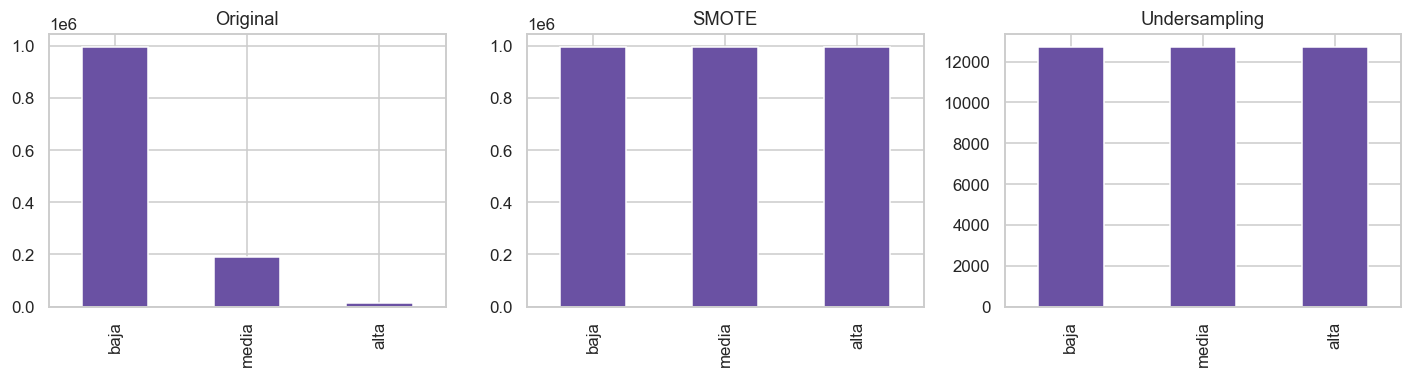

In [48]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

feat_bal = ["runtime_cap", "vote_count_log", "n_generos", "anio", "tiene_budget", "tiene_revenue"]
Xb = train_df[feat_bal].fillna(train_df[feat_bal].median())
yb = train_df["popularity_cat"]

probs = yb.value_counts(normalize=True)
H = -(probs * np.log2(probs)).sum()
print(f"Entropía de Shannon del target (train): {H:.3f} (máx {np.log2(len(probs)):.3f})")
print("Distribución original (train):", yb.value_counts().to_dict())

X_sm, y_sm = SMOTE(random_state=42).fit_resample(Xb, yb)
X_us, y_us = RandomUnderSampler(random_state=42).fit_resample(Xb, yb)
print("Tras SMOTE (solo train):", y_sm.value_counts().to_dict())
print("Tras undersampling (solo train):", y_us.value_counts().to_dict())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (titulo, serie) in zip(axes, [("Original", yb), ("SMOTE", y_sm), ("Undersampling", y_us)]):
    serie.value_counts().reindex(["baja", "media", "alta"]).plot.bar(ax=ax, color="#6a51a3")
    ax.set_title(titulo)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Lectura y decisión.** La distribución original (~83% baja / 16% media / 1% alta) tiene entropía de Shannon baja respecto del máximo, lo que confirma el fuerte desbalance (una clase domina). SMOTE (oversampling: genera ejemplos sintéticos de las clases minoritarias) y RandomUnderSampler (undersampling: recorta la mayoritaria) igualan las tres clases, pero solo se aplicarían sobre train. Como este es un EDA sin un modelo a entrenar, no adoptamos ningún rebalanceo: se deja la distribución real y el bloque queda para dejar visto el criterio.

### 5.12 Nota sobre *data drift*

Al aplicar las transformaciones de train a test pueden aparecer dos problemas: categorías presentes en test y ausentes en train, y valores de test fuera del rango observado en train. En este pipeline ambos ya están cubiertos por diseño: las categorías no vistas caen en "otros" (OHE y multi-hot con listas aprendidas en train) y los rangos/medianas se aprenden solo en train, que es la salvaguarda ante el drift.

### 5.13 Dataset final

Cerramos la preparación eliminando **todas las columnas originales ya procesadas** (identificadores redundantes, URLs, texto libre y categóricas crudas): quedaron reemplazadas por sus indicadores, largos, conteos y codificaciones. Se conserva `id` como clave, las numéricas tratadas y las nuevas features. Mostramos el shape y las columnas del dataset resultante para train y test.

In [49]:
# Se eliminan las columnas originales ya procesadas (y las intermedias auxiliares status_3/lang_top).
cols_drop = [
    "title", "original_title", "imdb_id",              # A
    "homepage", "backdrop_path", "poster_path",        # B
    "overview", "tagline",                             # C
    "status", "status_3",                              # D
    "original_language", "lang_top",                   # E
    "spoken_languages", "production_countries",        # F
    "production_companies", "keywords",
    "runtime", "runtime_imp", "vote_count", "genres",  # crudas ya reemplazadas por versiones tratadas
]
train_final = train_df.drop(columns=[c for c in cols_drop if c in train_df.columns])
test_final  = test_df.drop(columns=[c for c in cols_drop if c in test_df.columns])

print(f"Dataset final -> train: {train_final.shape} | test: {test_final.shape}")
obj_rest = [c for c in train_final.columns if train_final[c].dtype == "object"]
print("Columnas object restantes (deberían ser ninguna):", obj_rest or "ninguna")
print("Columnas del dataset final (", len(train_final.columns), "):")
print(sorted(train_final.columns.tolist()))

Dataset final -> train: (1199797, 93) | test: (299952, 93)
Columnas object restantes (deberían ser ninguna): ninguna
Columnas del dataset final ( 93 ):
['adult', 'anio', 'comp_20th Century Fox', 'comp_ARTE', 'comp_BBC', 'comp_Columbia Pictures', 'comp_Evil Angel', 'comp_Metro-Goldwyn-Mayer', 'comp_Nikkatsu Corporation', 'comp_ONF | NFB', 'comp_Paramount', 'comp_Private', 'comp_TOHO', 'comp_Toei Company', 'comp_Universal Pictures', 'comp_Warner Bros. Pictures', 'comp_ZDF', 'comp_otros', 'decada', 'id', 'lang_de', 'lang_en', 'lang_es', 'lang_fr', 'lang_hab_Arabic', 'lang_hab_Czech', 'lang_hab_English', 'lang_hab_French', 'lang_hab_German', 'lang_hab_Hindi', 'lang_hab_Italian', 'lang_hab_Japanese', 'lang_hab_Korean', 'lang_hab_Mandarin', 'lang_hab_No Language', 'lang_hab_Portuguese', 'lang_hab_Russian', 'lang_hab_Spanish', 'lang_hab_Swedish', 'lang_hab_otros', 'lang_it', 'lang_ja', 'lang_ko', 'lang_otros', 'lang_pt', 'lang_ru', 'lang_zh', 'len_overview', 'len_tagline', 'mes', 'n_companias

## 6. Conclusiones globales

- **Calidad de datos:** revenue y budget faltan en 98.3% y 94.1% de las 1.499.934 filas (estructural: TMDB no reporta finanzas para la mayoría del catálogo, que incluye producciones masivas sin datos comerciales). runtime falta ~32% de forma pareja entre décadas y géneros (MCAR/MAR).
- **vote_average** es la variable más simétrica del foco: media 6.16, mediana 6.0, skew -0.16 — se comporta como una calificación acotada (0-10), no como un monto o conteo.
- **budget, revenue, vote_count y popularity** muestran asimetría extrema hacia la derecha (popularity: skew 197.7, kurt 64363; revenue media 35.8M vs mediana 595k), con outliers reales (títulos de gran recaudación o muy vistos), no errores. Los extremos de `runtime` (hasta 14400 min) también son obras reales de larga duración. Los únicos errores de carga verificados son ~35 filas en la cola alta de budget/revenue: valores imposibles sobre títulos falsos o videojuegos, con fecha faltante o futura.
- **budget se asocia con revenue**: Pearson 0.56 pero Spearman 0.90 — la asociación monótona es mucho más fuerte que la lineal; el gap se explica por la asimetría de ambas variables, que Pearson subestima.
- **vote_average tiene asociación débil con el resto** (Pearson ≈0 con todas, Spearman vote_average–vote_count -0.11 y vote_average–runtime 0.04): la calificación promedio no acompaña de forma marcada al dinero, los votos ni la duración.
- **Géneros diversos:** 19 géneros con entropía H/H_max=0.862 (bastante parejo), aunque Drama (271.227), Documentary (206.420) y Comedy (164.692) dominan el conteo de películas-género.
- **Preparación (Clase 5):** para la etapa de preparación tratamos `popularity` como target de clasificación discretizándola por umbrales (baja/media/alta), lo que da clases desbalanceadas (~83% / 16% / 1%). Se crearon features temporales (`anio`, `decada`, `mes`) y `n_generos`; se discretizó `vote_average` con `qcut`; se escalaron las numéricas con Z-score (Pearson invariante); se discutió KNN/MICE como alternativa multivariada más costosa (se mantiene la mediana), y se trató el desbalance con SMOTE/undersampling solo en train.
- **Nota de cierre:** todo lo anterior describe asociaciones estadísticas (Pearson/Spearman/η²), no relaciones de causa-efecto. Y una salvedad de modelado: si fuéramos a entrenar un modelo, lo más probable es que sacáramos el `revenue`, ya que difícilmente sea un valor a tener para predecir la popularity de una película.